<a href="https://colab.research.google.com/github/Prathyusha-dev-hash/Chat-Bot/blob/main/VoltRelay_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VoltRelay Energy — What is really driving service failures, churn and margin erosion?
**Gradient Learnings Data Analytics Hackathon · Battery-swapping network analysis (Jan 2024 – Jun 2025)**

This notebook runs top to bottom. It covers data understanding, data cleaning (every documented data-quality issue is tested and handled), a unit-economics model, the six core questions, three optional deep dives (budget decision, expansion waves, support-ticket text) and a findings summary.

**How to run in Google Colab:** upload the hackathon zip (or the eight CSVs) to your Google Drive or to the Colab session. The loader below searches `/content`, `/content/drive/MyDrive` and the working directory for `swap_events.csv` or `swap_events.csv.gz` and will unzip the hackathon zip automatically if it finds it. If your files live elsewhere, set `DATA_DIR` manually in the next cell.

| Section | Contents |
|---|---|
| 0 | Setup and data loading |
| 1 | Data understanding |
| 2 | Data cleaning |
| 3 | Unit-economics (contribution margin) model |
| 4 | Q1 Network performance over time |
| 5 | Q2 Service failures and customer experience |
| 6 | Q3 Station and geographic patterns (incl. expansion waves) |
| 7 | Q4 Battery and equipment performance |
| 8 | Q5 Pricing and partner economics |
| 9 | Q6 Root cause analysis of retention |
| 10 | Deep dives: support-ticket text, anomalies, the budget decision |
| 11 | Key findings and recommendations |

## 0. Setup and data loading

In [6]:
# Optional: mount Google Drive when running in Colab
DATA_DIR ='/content/Hackathon Data Set _ Gradient-20260926T092843Z-1-001.zip'   # set to a folder path if auto-detection fails, e.g. '/content/drive/MyDrive/voltrelay'
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os, glob, zipfile, re, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
PALETTE = {'Gen1': '#d1495b', 'Gen2': '#edae49', 'Gen3': '#00798c'}
BLUE, RED, TEAL, GREY, ORANGE = '#30638e', '#d1495b', '#00798c', '#8d99ae', '#edae49'
os.makedirs('figures', exist_ok=True)

def save(fig, name):
    fig.tight_layout()
    fig.savefig(f'figures/{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

def locate_data(explicit=None):
    """Find the folder containing swap_events.csv(.gz); unzip the hackathon zip if needed."""
    if explicit and os.path.isdir(explicit):
        return explicit
    roots = ['.', '/content', '/content/drive/MyDrive', '/content/data', './data']
    for root in roots:
        hits = glob.glob(os.path.join(root, '**', 'swap_events.csv*'), recursive=True)
        if hits:
            return os.path.dirname(hits[0])
    for root in roots:
        for z in glob.glob(os.path.join(root, '*.zip')):
            try:
                with zipfile.ZipFile(z) as zf:
                    if any('swap_events' in n for n in zf.namelist()):
                        zf.extractall('./data')
                        hits = glob.glob('./data/**/swap_events.csv*', recursive=True)
                        return os.path.dirname(hits[0])
            except zipfile.BadZipFile:
                print(f"Warning: Skipping {z} as it is not a valid zip file.")
                continue # Skip to the next zip file
    raise FileNotFoundError('Could not find swap_events.csv(.gz). Set DATA_DIR in the cell above.')

DATA_DIR = locate_data(DATA_DIR)
def path(name):
    for ext in ('.csv', '.csv.gz'):
        p = os.path.join(DATA_DIR, name + ext)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(name)
print('Data folder:', DATA_DIR)
print(sorted(os.listdir(DATA_DIR)))

Data folder: ./data/Hackathon Data Set _ Gradient
['batteries.csv', 'city_daily_context.csv', 'fleet_partners.csv', 'riders.csv', 'station_hourly_status.csv', 'stations.csv', 'support_tickets.csv', 'swap_events.csv']


`swap_events` has 3.9 million rows, so it is read in chunks with compact data types (categories and 32-bit floats). The string `event_id` is converted to an integer to save memory after checking it is unique.

In [9]:
t0 = time.time()
CAT = ['rider_id', 'station_id', 'event_type', 'battery_in_id', 'battery_out_id', 'tariff_code',
       'payment_mode', 'station_firmware', 'sync_mode']
F32 = ['soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'list_price_inr',
       'discount_inr', 'amount_charged_inr', 'energy_to_recharge_kwh']
dtypes = {c: 'category' for c in CAT} | {c: 'float32' for c in F32} | {'queue_wait_sec': 'int32', 'attempt_seq': 'int8'}

chunks = []
for ch in pd.read_csv(path('swap_events'), dtype=dtypes, chunksize=500_000):
    ch['event_id'] = ch['event_id'].str[3:].astype('int64')
    ch['event_ts'] = pd.to_datetime(ch['event_ts'])
    chunks.append(ch)
swaps_raw = pd.concat(chunks, ignore_index=True)
del chunks
for c in CAT:   # concat can demote categories with differing levels to object; re-categorise
    if swaps_raw[c].dtype != 'category':
        swaps_raw[c] = swaps_raw[c].astype('category')

hourly_raw = pd.read_csv(path('station_hourly_status'), dtype={'station_id': 'category', 'telemetry_status': 'category'},
                         parse_dates=['hour_start'])
riders_raw = pd.read_csv(path('riders'), parse_dates=['signup_date'])
batteries = pd.read_csv(path('batteries'), parse_dates=['manufacture_date', 'commission_date', 'retired_date'])
tickets_raw = pd.read_csv(path('support_tickets'), parse_dates=['created_ts'])
stations = pd.read_csv(path('stations'), parse_dates=['commissioned_date', 'decommissioned_date',
                                                     'firmware_updated_date', 'competitor_within_1_5km_since'])
city_ctx = pd.read_csv(path('city_daily_context'), parse_dates=['date'])
partners = pd.read_csv(path('fleet_partners'), parse_dates=['contract_start_date', 'amendment_date'])
print(f'Loaded in {time.time()-t0:.0f}s')

Loaded in 52s


## 1. Data understanding

In [10]:
tables = {'swap_events': swaps_raw, 'station_hourly_status': hourly_raw, 'riders': riders_raw, 'batteries': batteries,
          'support_tickets': tickets_raw, 'stations': stations, 'city_daily_context': city_ctx, 'fleet_partners': partners}
overview = pd.DataFrame({n: {'rows': len(d), 'columns': d.shape[1],
                             'memory_MB': round(d.memory_usage(deep=True).sum() / 1e6, 1),
                             'cells_missing_%': round(d.isna().mean().mean() * 100, 1)} for n, d in tables.items()}).T
overview

,rows,columns,memory_MB,cells_missing_%
swap_events,"3,877,013.00",22.00,274.40,1.20
station_hourly_status,"1,487,712.00",14.00,147.30,4.30
riders,"20,000.00",12.00,11.30,5.30
batteries,"6,500.00",13.00,2.50,12.00
support_tickets,"44,000.00",12.00,25.20,9.60
stations,152.00,22.00,0.10,8.80
city_daily_context,"3,282.00",12.00,0.40,8.10
fleet_partners,12.00,12.00,0.00,15.30


In [11]:
print('Primary-key checks')
print('  swap_events.event_id unique:', swaps_raw.event_id.is_unique)
print('  riders.rider_id unique:', riders_raw.rider_id.is_unique)
print('  batteries.battery_id unique:', batteries.battery_id.is_unique)
print('  stations.station_id unique:', stations.station_id.is_unique)
print('  hourly (station, hour) unique:', not hourly_raw.duplicated(['station_id', 'hour_start']).any())
print('Foreign-key checks')
print('  swap riders found in riders:', swaps_raw.rider_id.isin(riders_raw.rider_id).mean().round(4))
print('  swap stations found in stations:', swaps_raw.station_id.isin(stations.station_id).mean().round(4))
print('  event_ts range:', swaps_raw.event_ts.min(), '→', swaps_raw.event_ts.max())

Primary-key checks
  swap_events.event_id unique: True
  riders.rider_id unique: True
  batteries.battery_id unique: True
  stations.station_id unique: True
  hourly (station, hour) unique: True
Foreign-key checks
  swap riders found in riders: 1.0
  swap stations found in stations: 1.0
  event_ts range: 2024-01-01 00:00:33 → 2025-06-30 23:59:23


In [12]:
print('Event outcomes (share of attempts):')
display(swaps_raw.event_type.value_counts(normalize=True).mul(100).round(2).to_frame('% of attempts'))
print('Missing values in swap_events (%):')
display(swaps_raw.isna().mean().mul(100).round(1).to_frame('% missing').query('`% missing` > 0'))
display(pd.crosstab(swaps_raw.tariff_code, swaps_raw.event_type))

Event outcomes (share of attempts):


,% of attempts
event_type,
swap_completed,94.04
failed_no_charged_battery,3.47
abandoned_queue,1.77
cancelled_by_rider,0.43
failed_system_error,0.30


Missing values in swap_events (%):


,% missing
battery_in_id,0.70
battery_out_id,6.00
soc_in_pct,0.70
soh_in_pct,0.70
soc_out_pct,6.00
soh_out_pct,6.00
km_since_last_swap,0.70
energy_to_recharge_kwh,6.00


event_type,abandoned_queue,cancelled_by_rider,failed_no_charged_battery,failed_system_error,swap_completed
tariff_code,,,,,
OFFPEAK,467,150,888,117,36098
PARTNER,46274,11080,90652,7631,2409841
PEAK,2369,789,4351,537,169833
STD,19423,4693,38498,3285,1030037


**What the structure tells us**

About 94% of attempts complete. Price and energy fields are populated as the dictionary describes: `battery_out_id`, `soc_out_pct`, `soh_out_pct` and `energy_to_recharge_kwh` exist only for completed swaps, while `amount_charged_inr` is zero for every non-completed attempt. Revenue and cost analysis therefore uses completed swaps only, while service-quality analysis uses all attempts.

Two schema surprises worth recording: `payment_mode` is `partner_invoice` on every single row (so it carries no information and is dropped), and the `PREPAID` and `PROMO_FREE` tariff codes described in the dictionary never occur.

In [13]:
print('payment_mode values:', swaps_raw.payment_mode.value_counts().to_dict())
print('tariff codes present:', sorted(swaps_raw.tariff_code.dropna().unique().tolist()))

payment_mode values: {'partner_invoice': 3877013}
tariff codes present: ['OFFPEAK', 'PARTNER', 'PEAK', 'STD']


## 2. Data cleaning
Each documented data-quality issue is tested before it is handled, so every cleaning step is backed by evidence.

### 2.1 Test stations (`STN-TST-*`)

In [14]:
tst = swaps_raw.station_id.astype(str).str.startswith('STN-TST')
print(f'Test-station events: {tst.sum():,} ({tst.mean():.2%} of all attempts)')
print('Zero-value events at test stations:', (swaps_raw.loc[tst, 'amount_charged_inr'] == 0).sum())
# The docs describe "a small number of zero-value transactions"; the export actually contains ~62k ordinary-looking
# events at two co-located test cabinets. They are internal equipment, not customer sites, so they are excluded.

Test-station events: 62,031 (1.60% of all attempts)
Zero-value events at test stations: 2897


The documentation describes only "a small number of zero-value transactions", but the export contains about 62,000 ordinary-looking events at the two test cabinets (1.6% of attempts). Because these are internal test cabinets rather than customer sites, all of them are excluded from network analysis. This is flagged as an anomaly in section 10.

### 2.2 Firmware v3.2.0 timestamp bug (Mar 10 – Apr 14 2025)

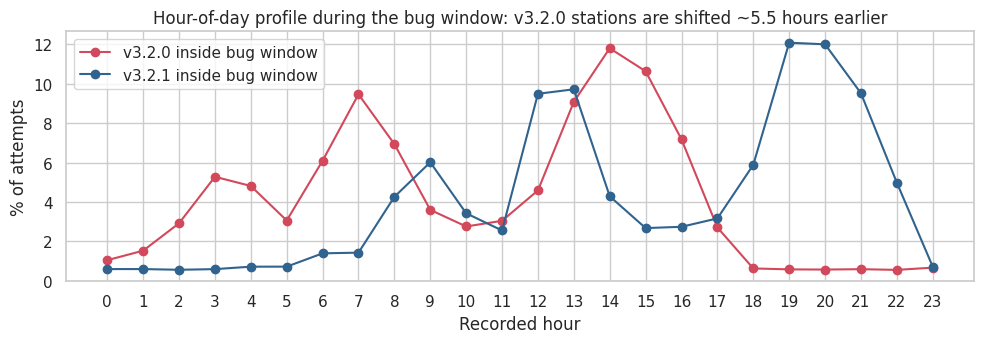

In [15]:
win = (swaps_raw.event_ts >= '2025-03-10') & (swaps_raw.event_ts < '2025-04-15')
fw320 = swaps_raw.station_firmware == 'v3.2.0'
hod = pd.DataFrame({
    'v3.2.0 inside bug window': swaps_raw.loc[fw320 & win, 'event_ts'].dt.hour.value_counts(normalize=True),
    'v3.2.1 inside bug window': swaps_raw.loc[~fw320 & win, 'event_ts'].dt.hour.value_counts(normalize=True),
}).sort_index() * 100
fig, ax = plt.subplots(figsize=(10, 3.6))
hod.plot(ax=ax, marker='o', color=[RED, BLUE])
ax.set(title='Hour-of-day profile during the bug window: v3.2.0 stations are shifted ~5.5 hours earlier',
       xlabel='Recorded hour', ylabel='% of attempts'); ax.set_xticks(range(24))
save(fig, '00_firmware_bug')

In [16]:
bug_mask = fw320 & win
swaps_raw.loc[bug_mask, 'event_ts'] += pd.Timedelta(hours=5, minutes=30)
print(f'Corrected {bug_mask.sum():,} timestamps (+5h30m)')

Corrected 139,490 timestamps (+5h30m)


The bug is confirmed: inside the window, the v3.2.0 profile peaks around 07:00 and 14:00, while v3.2.1 stations peak at 12:00–13:00 and 19:00–21:00. Adding 5h30m realigns the two profiles, so all hour-of-day analysis below uses the corrected time.

### 2.3 Near-duplicate offline-sync records

In [17]:
KEYS = ['rider_id', 'station_id', 'battery_in_id', 'battery_out_id', 'event_type']
s = pd.DataFrame({c: swaps_raw[c].cat.codes for c in KEYS})          # integer codes: fast and memory-light
s['event_ts'] = swaps_raw.event_ts
s = s.sort_values(KEYS + ['event_ts'])
same = s[KEYS].eq(s[KEYS].shift()).all(axis=1)
gap = s.event_ts.diff().dt.total_seconds()
dup_idx = s.index[same & (gap <= 180)]
print(f'Near-duplicates (same rider, station, batteries and outcome within 3 min): {len(dup_idx):,}')
print('Of which offline_batch:', (swaps_raw.loc[dup_idx, 'sync_mode'] == 'offline_batch').sum())
s = s.sort_values(['rider_id', 'station_id', 'event_ts'])
g2 = s.event_ts.diff().dt.total_seconds()
loose_same = s.rider_id.eq(s.rider_id.shift()) & s.station_id.eq(s.station_id.shift()) & (g2 <= 180)
print(f'Looser check, same rider and station within 3 min (any battery): {loose_same.sum():,} '
      f'({loose_same.mean():.2%}); these have different battery IDs, so they are distinct swaps')
swaps_raw = swaps_raw.drop(index=dup_idx)
del s

Near-duplicates (same rider, station, batteries and outcome within 3 min): 0
Of which offline_batch: 0
Looser check, same rider and station within 3 min (any battery): 6,467 (0.17%); these have different battery IDs, so they are distinct swaps


The documented pattern (same rider, station and batteries, seconds apart, flagged `offline_batch`) does not appear in this export: the strict rule finds essentially no matches. Close-together events at the same station always involve different battery packs, so they are real, separate swaps. The strict rule is still applied (it removes nothing material), and the result is recorded as a finding rather than silently assumed.

### 2.4 Outliers in distance and charge readings

In [18]:
km = swaps_raw.km_since_last_swap
print(f'km < 0: {(km < 0).sum():,}   km > 250: {(km > 250).sum():,}   (99th pct = {km.quantile(.99):.0f} km)')
print('SoC/SoH readings above 100%:', {c: int((swaps_raw[c] > 100).sum()) for c in ['soc_in_pct', 'soc_out_pct', 'soh_in_pct', 'soh_out_pct']})
swaps_raw.loc[(km < 0) | (km > 250), 'km_since_last_swap'] = np.nan   # odometer resets → unknown
for c in ['soc_in_pct', 'soc_out_pct', 'soh_in_pct', 'soh_out_pct']:
    swaps_raw[c] = swaps_raw[c].clip(upper=100)                     # calibration drift → cap at 100

km < 0: 7,814   km > 250: 7,712   (99th pct = 107 km)
SoC/SoH readings above 100%: {'soc_in_pct': 0, 'soc_out_pct': 3698, 'soh_in_pct': 3356, 'soh_out_pct': 2799}


### 2.5 Rider city spellings

In [19]:
CITY_MAP = {'bengaluru': 'Bengaluru', 'bangalore': 'Bengaluru', 'blr': 'Bengaluru',
            'delhi ncr': 'Delhi NCR', 'new delhi': 'Delhi NCR', 'delhi': 'Delhi NCR', 'gurgaon': 'Delhi NCR',
            'hyderabad': 'Hyderabad', 'hyd': 'Hyderabad', 'pune': 'Pune', 'pun': 'Pune',
            'mumbai': 'Mumbai', 'bombay': 'Mumbai', 'mum': 'Mumbai', 'jaipur': 'Jaipur', 'jai': 'Jaipur'}
riders = riders_raw.copy()
riders['home_city_clean'] = riders.home_city.str.strip().str.lower().map(CITY_MAP)
print('Distinct raw spellings:', riders.home_city.nunique(), '→ clean cities:', riders.home_city_clean.nunique(),
      '| unmapped:', riders.home_city_clean.isna().sum())
riders.groupby('home_city_clean').home_city.unique()

Distinct raw spellings: 21 → clean cities: 6 | unmapped: 0


,home_city
home_city_clean,
Bengaluru,"[Bengaluru, bengaluru , Bangalore, BLR]"
Delhi NCR,"[Delhi NCR, Gurgaon, New Delhi, Delhi]"
Hyderabad,"[Hyderabad, hyderabad, HYD, Hyd]"
Jaipur,"[Jaipur, jaipur, JAI]"
Mumbai,"[Mumbai, Bombay, MUM]"
Pune,"[Pune, PUN, pune]"


### 2.6 Telemetry gaps, ticket dates and CSAT

In [20]:
hourly = hourly_raw[~hourly_raw.station_id.astype(str).str.startswith('STN-TST')].copy()
tel = hourly.merge(stations[['station_id', 'connectivity_tier']], on='station_id')
display(pd.crosstab(tel.connectivity_tier, tel.telemetry_status, normalize='index').mul(100).round(2))
# Blank telemetry is left as NaN (never zero-filled); stock/temperature analysis uses rows with telemetry_status == 'ok'.

tickets = tickets_raw.copy()
out_of_range = ~tickets.created_ts.between('2024-01-01', '2025-06-30 23:59:59')
print(f'Tickets dated outside Jan-2024..Jun-2025: {out_of_range.sum()} (excluded from trend charts)')
tickets['in_window'] = ~out_of_range

resp = tickets.groupby(pd.cut(tickets.resolution_hours, [0, 12, 24, 48, 500])).csat_score.agg(
    response_rate=lambda s: s.notna().mean(), mean_csat='mean')
display(resp)

telemetry_status,missing,ok,partial
connectivity_tier,,,
fair,0.00,96.05,3.95
good,0.00,98.99,1.01
poor,4.00,89.10,6.90


Tickets dated outside Jan-2024..Jun-2025: 86 (excluded from trend charts)


,response_rate,mean_csat
resolution_hours,,
"(0, 12]",0.44,3.54
"(12, 24]",0.43,3.57
"(24, 48]",0.21,3.60
"(48, 500]",0.22,3.64


Missing telemetry is concentrated at poor-connectivity stations. It is kept as missing, never zero-filled, because zero-filling would fabricate stock-outs.

CSAT is answered by about 44% of tickets resolved within 24 hours, but only about 21% of slower ones, confirming the "not missing at random" warning. Because the recorded scores barely vary with resolution time, CSAT is treated as an unreliable outcome and is not used to rank problems.

### 2.7 Build the clean analysis tables

In [21]:
swaps = swaps_raw[~swaps_raw.station_id.astype(str).str.startswith('STN-TST')].copy()
del swaps_raw
swaps['station_id'] = swaps.station_id.cat.remove_unused_categories()
swaps = swaps.drop(columns=['attempt_seq', 'payment_mode'])

st_cols = ['station_id', 'city', 'zone', 'location_type', 'host_type', 'expansion_wave', 'charger_generation',
           'connectivity_tier', 'grid_tariff_inr_kwh', 'competitor_within_1_5km_since']
swaps = swaps.merge(stations[st_cols], on='station_id', how='left')
swaps = swaps.merge(riders[['rider_id', 'partner_id', 'vehicle_class', 'plan_type', 'signup_date', 'signup_channel']],
                    on='rider_id', how='left')
for c in ['station_id', 'rider_id', 'city', 'zone', 'location_type', 'host_type', 'expansion_wave', 'charger_generation',
          'connectivity_tier', 'partner_id', 'vehicle_class', 'plan_type', 'signup_channel']:
    swaps[c] = swaps[c].astype('category')

swaps['completed'] = swaps.event_type.eq('swap_completed')
swaps['failed'] = ~swaps.completed
swaps['no_battery'] = swaps.event_type.eq('failed_no_charged_battery')
swaps['abandoned'] = swaps.event_type.eq('abandoned_queue')
swaps['month'] = swaps.event_ts.dt.to_period('M').dt.to_timestamp()
swaps['hour'] = swaps.event_ts.dt.hour.astype('int8')
swaps['date'] = swaps.event_ts.dt.normalize()
swaps['summer'] = swaps.event_ts.dt.month.isin([4, 5, 6])          # Apr-Jun = pre-monsoon heat season
swaps['hot_city'] = swaps.city.isin(['Delhi NCR', 'Jaipur', 'Hyderabad'])
print(f'Clean attempts: {len(swaps):,} | completed swaps: {swaps.completed.sum():,} | stations: {swaps.station_id.nunique()}')

Clean attempts: 3,814,982 | completed swaps: 3,586,675 | stations: 150


## 3. Unit-economics model: contribution margin per swap

The dataset has revenue and cost drivers, but no cost ledger, so a transparent per-swap margin model is built. All assumptions are listed so leadership can change them.

| Component | How it is computed |
|---|---|
| Revenue | `amount_charged_inr` on completed swaps |
| Energy cost | `energy_to_recharge_kwh` × station `grid_tariff_inr_kwh` |
| Battery wear | For each pack: purchase cost × (SoH points lost per swap ÷ usable SoH points). Usable points run from the pack's initial SoH down to **60%**, the level at which VoltRelay actually retired packs in June 2025. |
| Station cost | (monthly rent + maintenance) ÷ completed swaps at that station that month |

**CM1** = revenue − energy − battery wear (the variable margin). **CM2** = CM1 − station cost (the fully loaded margin).

In [22]:
RETIRE_SOH = 60.0
comp = swaps[swaps.completed].copy()
issued = comp.battery_out_id.astype(str).value_counts()
batteries['swaps_issued'] = batteries.battery_id.map(issued).fillna(0)
batteries['soh_lost'] = batteries.initial_soh_pct - batteries.current_soh_pct
batteries['soh_lost_per_100_swaps'] = batteries.soh_lost / batteries.swaps_issued.replace(0, np.nan) * 100
batteries['wear_inr_per_swap'] = (batteries.purchase_cost_inr * (batteries.soh_lost / batteries.swaps_issued.replace(0, np.nan))
                                  / (batteries.initial_soh_pct - RETIRE_SOH))
BAD_LOTS = ['KY-2407', 'KY-2408', 'KY-2409']
batteries['cohort'] = np.where(batteries.manufacturing_lot.isin(BAD_LOTS), 'Kyron KY-2407/08/09', batteries.supplier)

comp = comp.merge(batteries[['battery_id', 'wear_inr_per_swap', 'supplier', 'manufacturing_lot', 'cohort']],
                  left_on=comp.battery_out_id.astype(str), right_on='battery_id', how='left').drop(columns=['key_0'], errors='ignore')
stations['fixed_monthly'] = stations.monthly_rent_inr + stations.monthly_maintenance_inr
sm = comp.groupby(['station_id', 'month'], observed=True).size().rename('n').reset_index()
sm = sm.merge(stations[['station_id', 'fixed_monthly']], on='station_id')
sm['station_cost'] = sm.fixed_monthly / sm.n
comp = comp.merge(sm[['station_id', 'month', 'station_cost']], on=['station_id', 'month'], how='left')
comp['revenue'] = comp.amount_charged_inr.astype(float)
comp['energy_cost'] = comp.energy_to_recharge_kwh * comp.grid_tariff_inr_kwh
comp['wear_cost'] = comp.wear_inr_per_swap
comp['cm1'] = comp.revenue - comp.energy_cost - comp.wear_cost
comp['cm2'] = comp.cm1 - comp.station_cost
comp['partner'] = comp.partner_id.astype(str).replace({'nan': 'Independent'})
print('Average unit economics per completed swap (INR):')
display(comp[['revenue', 'energy_cost', 'wear_cost', 'station_cost', 'cm1', 'cm2']].mean().round(2).to_frame('INR / swap').T)
display(batteries.groupby('cohort')[['wear_inr_per_swap']].median().round(1))

Average unit economics per completed swap (INR):


,revenue,energy_cost,wear_cost,station_cost,cm1,cm2
INR / swap,63.90,19.49,36.92,13.41,7.49,-5.92


,wear_inr_per_swap
cohort,
Amptek,24.80
Cellora,24.70
Kyron,57.40
Kyron KY-2407/08/09,78.90


**Reading the unit economics.** On a fully loaded basis (CM2), the average swap is slightly below break-even. Battery wear is the largest cost line, larger than energy. The absolute level of CM2 depends on the wear assumption, so the analysis below leans on **trends and relative comparisons** (month to month, partner to partner, cohort to cohort), which are robust to that assumption. A sensitivity check is included at the end of section 8.

## 4. Q1 — Network performance over time

In [23]:
m_att = swaps.groupby('month').agg(attempts=('completed', 'size'), completed=('completed', 'sum'),
                                   failure_rate=('failed', 'mean'), no_battery=('no_battery', 'mean'),
                                   abandoned=('abandoned', 'mean'), failures=('failed', 'sum'))
m_cm = comp.groupby('month').agg(revenue=('revenue', 'sum'), rev_per_swap=('revenue', 'mean'),
                                 energy=('energy_cost', 'mean'), wear=('wear_cost', 'mean'),
                                 station=('station_cost', 'mean'), cm1=('cm1', 'mean'), cm2=('cm2', 'mean'))
monthly = m_att.join(m_cm)
monthly[['failure_rate', 'no_battery', 'abandoned']] *= 100
monthly.round(2)

,attempts,completed,failure_rate,no_battery,abandoned,failures,revenue,rev_per_swap,energy,wear,station,cm1,cm2
month,,,,,,,,,,,,,
2024-01-01,108278,103508,4.41,2.44,1.27,4770,"6,198,803.40",59.89,22.01,28.84,20.38,9.05,-11.33
2024-02-01,109271,104437,4.42,2.40,1.30,4834,"6,256,296.00",59.90,21.90,28.85,20.19,9.16,-11.04
2024-03-01,121487,116148,4.39,2.37,1.27,5339,"6,952,642.00",59.86,21.71,28.76,18.16,9.39,-8.77
2024-04-01,128991,120117,6.88,4.13,2.05,8874,"7,204,036.20",59.98,21.60,28.84,17.56,9.54,-8.02
2024-05-01,143189,125454,12.39,7.82,3.81,17735,"7,513,212.80",59.89,21.33,28.76,16.81,9.80,-7.02
2024-06-01,145880,130880,10.28,6.43,3.12,15000,"7,827,373.00",59.81,21.03,28.67,16.11,10.11,-6.01
2024-07-01,155343,148611,4.33,2.35,1.28,6732,"9,666,799.25",65.05,20.86,28.70,14.19,15.49,1.30
2024-08-01,168900,161688,4.27,2.29,1.26,7212,"10,509,533.60",65.00,20.65,28.69,14.67,15.66,0.99
2024-09-01,192479,184051,4.38,2.39,1.25,8428,"11,903,273.70",64.67,20.46,37.23,13.85,6.99,-6.86


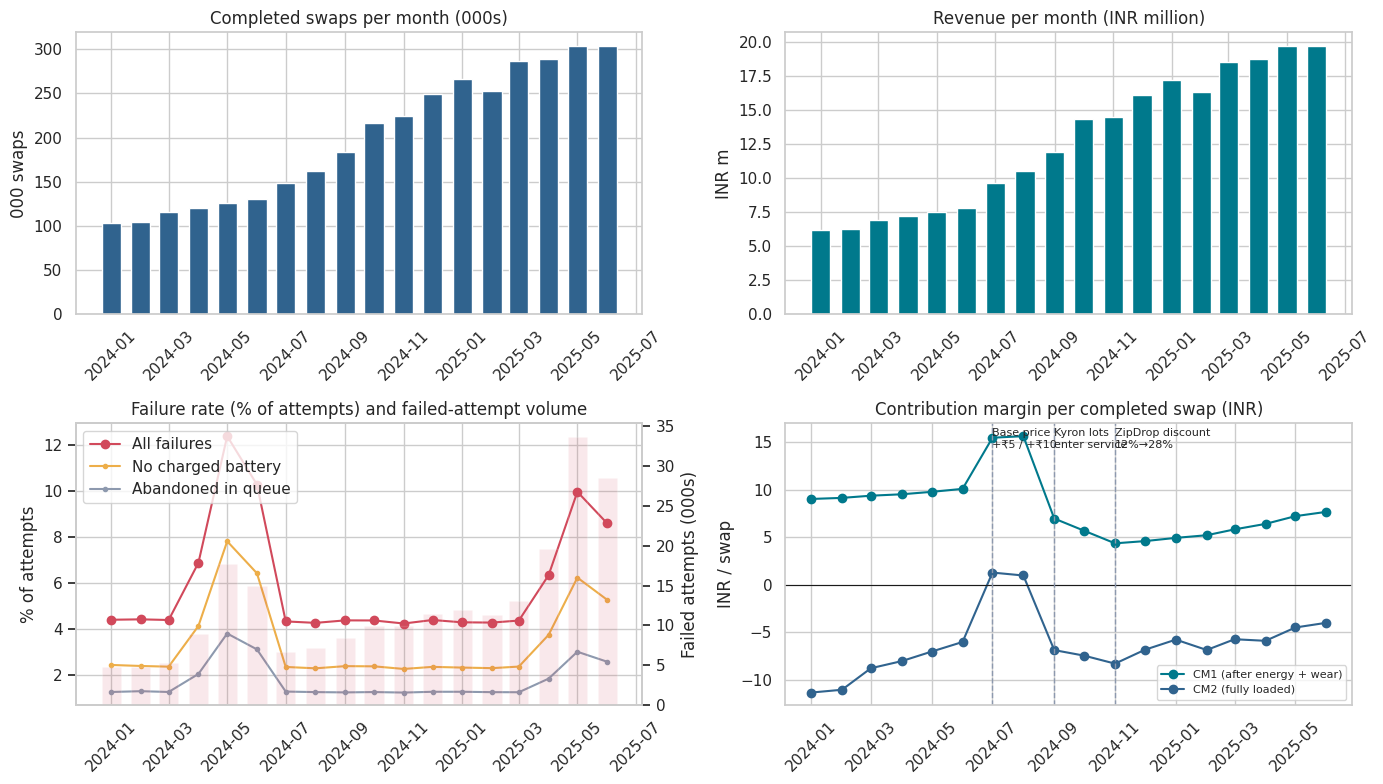

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
ax = axes[0, 0]; ax.bar(monthly.index, monthly.completed / 1e3, width=20, color=BLUE)
ax.set(title='Completed swaps per month (000s)', ylabel='000 swaps')
ax = axes[0, 1]; ax.bar(monthly.index, monthly.revenue / 1e6, width=20, color=TEAL)
ax.set(title='Revenue per month (INR million)', ylabel='INR m')
ax = axes[1, 0]; ax.plot(monthly.index, monthly.failure_rate, marker='o', color=RED, label='All failures')
ax.plot(monthly.index, monthly.no_battery, marker='.', color=ORANGE, label='No charged battery')
ax.plot(monthly.index, monthly.abandoned, marker='.', color=GREY, label='Abandoned in queue')
ax2 = ax.twinx(); ax2.bar(monthly.index, monthly.failures / 1e3, width=20, color=RED, alpha=.12); ax2.set_ylabel('Failed attempts (000s)'); ax2.grid(False)
ax.set(title='Failure rate (% of attempts) and failed-attempt volume', ylabel='% of attempts'); ax.legend(loc='upper left')
ax = axes[1, 1]; ax.plot(monthly.index, monthly.cm1, marker='o', color=TEAL, label='CM1 (after energy + wear)')
ax.plot(monthly.index, monthly.cm2, marker='o', color=BLUE, label='CM2 (fully loaded)')
ax.axhline(0, color='k', lw=.8)
for d, lab in [('2024-07-01', 'Base price\n+₹5 / +₹10'), ('2024-09-01', 'Kyron lots\nenter service'),
               ('2024-11-01', 'ZipDrop discount\n12%→28%')]:
    ax.axvline(pd.Timestamp(d), color=GREY, ls='--', lw=1); ax.text(pd.Timestamp(d), ax.get_ylim()[1] * .97, lab, fontsize=8, va='top')
ax.set(title='Contribution margin per completed swap (INR)', ylabel='INR / swap'); ax.legend(loc='lower right', fontsize=8)
for a in axes.flat: a.tick_params(axis='x', rotation=45)
save(fig, '01_network_trends')

In [25]:
h = monthly.loc[['2024-01-01', '2024-06-01', '2024-12-01', '2025-06-01'],
                ['completed', 'revenue', 'failure_rate', 'failures', 'rev_per_swap', 'wear', 'cm2']]
h

,completed,revenue,failure_rate,failures,rev_per_swap,wear,cm2
month,,,,,,,
2024-01-01,103508,"6,198,803.40",4.41,4770,59.89,28.84,-11.33
2024-06-01,130880,"7,827,373.00",10.28,15000,59.81,28.67,-6.01
2024-12-01,248954,"16,092,099.53",4.39,11443,64.64,40.40,-6.82
2025-06-01,303196,"19,690,790.32",8.60,28523,64.94,40.23,-3.99


In [26]:
yoy = pd.DataFrame({'Apr-Jun 2024': monthly.loc['2024-04':'2024-06'].sum(numeric_only=True),
                    'Apr-Jun 2025': monthly.loc['2025-04':'2025-06'].sum(numeric_only=True)}).loc[['completed', 'failures', 'revenue']]
yoy['growth_%'] = (yoy.iloc[:, 1] / yoy.iloc[:, 0] - 1) * 100
yoy

,Apr-Jun 2024,Apr-Jun 2025,growth_%
completed,"376,451.00","896,205.00",138.07
failures,"41,609.00","81,734.00",96.43
revenue,"22,544,622.00","58,153,468.20",157.95


**Q1 findings: the metrics do not tell the same story.**

Completed swaps grew about 2.9× (104k in Jan 2024 to 303k in Jun 2025), and revenue grew about 3.2×, helped by the July 2024 price rise.

The failure rate is not rising steadily. It is **seasonal**: it sits near 4.3% for nine months of the year and jumps to 10–12% every April to June. Because volume nearly doubled, the *number* of failed attempts in summer 2025 is roughly double summer 2024, so riders experienced far more failures even though the rate barely changed.

Margin per swap moved in the opposite direction from volume. The price rise lifted CM2 above zero in Jul–Aug 2024. It then fell back by about ₹8 a swap from September 2024, when defective Kyron battery lots entered service (wear cost up about 40%), and again in November 2024, when ZipDrop's discount rose from 12% to 28%. **Growth hid a deteriorating unit economy.**

## 5. Q2 — Service failures and customer experience

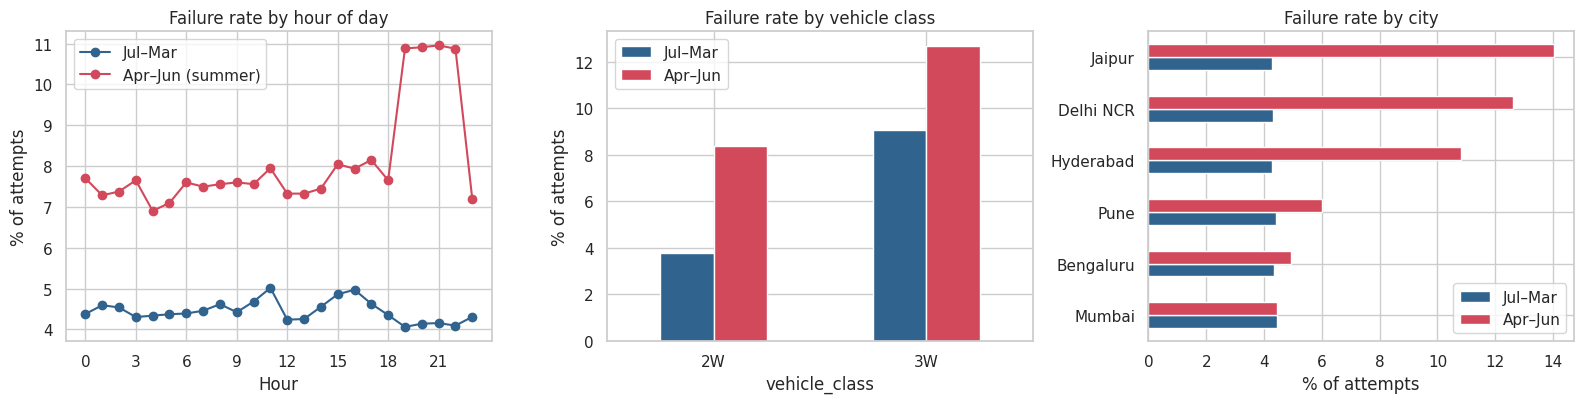

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
hr = swaps.pivot_table(index='hour', columns='summer', values='failed', aggfunc='mean') * 100
hr.columns = ['Jul–Mar', 'Apr–Jun (summer)']
hr.plot(ax=axes[0], marker='o', color=[BLUE, RED]); axes[0].set(title='Failure rate by hour of day', ylabel='% of attempts', xlabel='Hour'); axes[0].set_xticks(range(0, 24, 3))
vc = swaps.pivot_table(index='vehicle_class', columns='summer', values='failed', aggfunc='mean', observed=True) * 100
vc.columns = ['Jul–Mar', 'Apr–Jun']; vc.plot.bar(ax=axes[1], color=[BLUE, RED], rot=0); axes[1].set(title='Failure rate by vehicle class', ylabel='% of attempts')
cg = swaps.pivot_table(index='city', columns='summer', values='failed', aggfunc='mean', observed=True) * 100
cg.columns = ['Jul–Mar', 'Apr–Jun']; cg.sort_values('Apr–Jun').plot.barh(ax=axes[2], color=[BLUE, RED]); axes[2].set(title='Failure rate by city', xlabel='% of attempts', ylabel='')
save(fig, '02_failure_patterns')

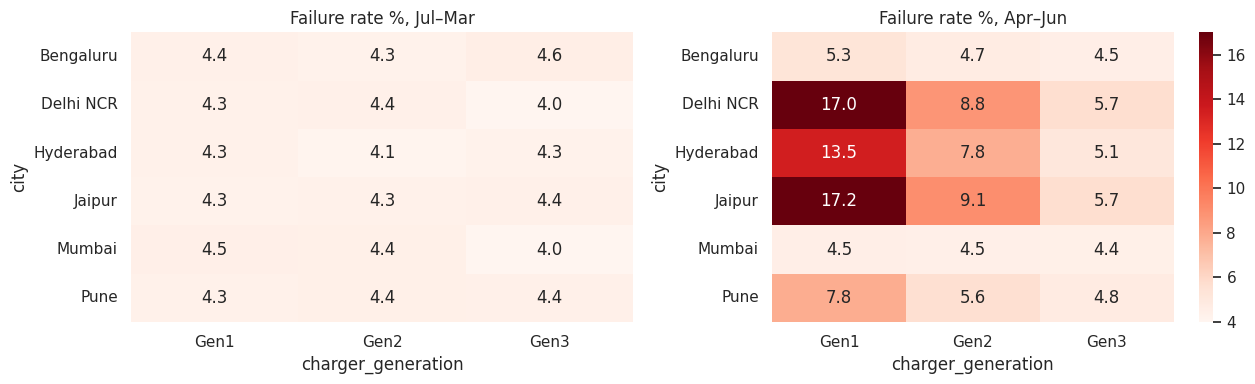

In [28]:
gen_city = (swaps[swaps.summer].pivot_table(index='city', columns='charger_generation', values='failed', aggfunc='mean', observed=True) * 100)
gen_city_off = (swaps[~swaps.summer].pivot_table(index='city', columns='charger_generation', values='failed', aggfunc='mean', observed=True) * 100)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(gen_city_off, annot=True, fmt='.1f', cmap='Reds', vmin=4, vmax=17, ax=axes[0], cbar=False); axes[0].set_title('Failure rate %, Jul–Mar')
sns.heatmap(gen_city, annot=True, fmt='.1f', cmap='Reds', vmin=4, vmax=17, ax=axes[1]); axes[1].set_title('Failure rate %, Apr–Jun')
save(fig, '03_city_generation_heatmap')

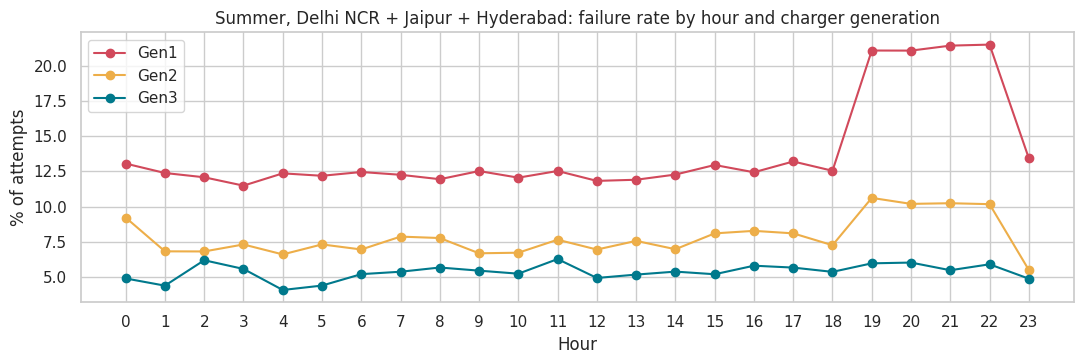

Summer × hot city × Gen1 = 11.6% of attempts but 30.4% of all failures
3W riders = 10.9% of attempts but 18.9% of failures


In [29]:
hot_hr = (swaps[swaps.summer & swaps.hot_city].pivot_table(index='hour', columns='charger_generation', values='failed', aggfunc='mean', observed=True) * 100)
fig, ax = plt.subplots(figsize=(11, 3.8))
for g in ['Gen1', 'Gen2', 'Gen3']:
    ax.plot(hot_hr.index, hot_hr[g], marker='o', color=PALETTE[g], label=g)
ax.set(title='Summer, Delhi NCR + Jaipur + Hyderabad: failure rate by hour and charger generation', xlabel='Hour', ylabel='% of attempts')
ax.set_xticks(range(24)); ax.legend(); save(fig, '04_hot_city_hourly')

seg = swaps.summer & swaps.hot_city & swaps.charger_generation.eq('Gen1')
print(f'Summer × hot city × Gen1 = {seg.mean():.1%} of attempts but {swaps.loc[seg, "failed"].sum() / swaps.failed.sum():.1%} of all failures')
print(f'3W riders = {swaps.vehicle_class.eq("3W").mean():.1%} of attempts but {swaps.loc[swaps.vehicle_class.eq("3W"), "failed"].sum() / swaps.failed.sum():.1%} of failures')

In [30]:
q = comp.groupby('summer').queue_wait_sec.describe()[['mean', '50%', '75%']]
print('Queue wait of *completed* swaps (seconds):'); display(q)
print('Mean queue wait before abandoning:', round(swaps.loc[swaps.abandoned, 'queue_wait_sec'].mean()), 's')

Queue wait of *completed* swaps (seconds):


,mean,50%,75%
summer,,,
False,243.77,209.00,304.00
True,243.63,210.00,304.00


Mean queue wait before abandoning: 703 s


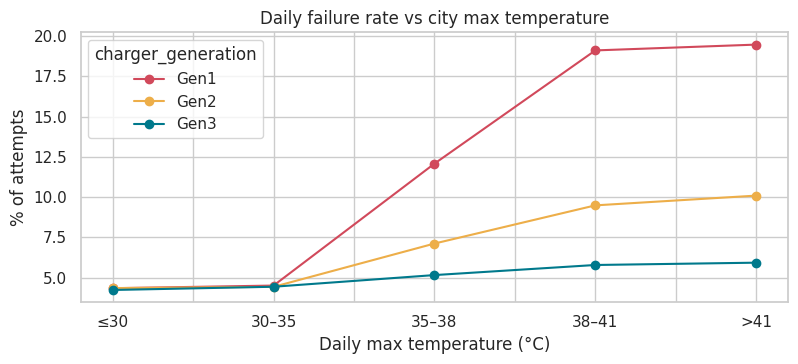

Heat-alert days vs others: {False: 5.2, True: 13.3}
Grid outage > 1h vs others: {False: 5.5, True: 12.7}


In [31]:
ctx = swaps.groupby(['city', 'date', 'charger_generation'], observed=True).failed.mean().reset_index().merge(city_ctx, on=['city', 'date'])
ctx['temp_band'] = pd.cut(ctx.max_temp_c, [0, 30, 35, 38, 41, 50], labels=['≤30', '30–35', '35–38', '38–41', '>41'])
tb = ctx.pivot_table(index='temp_band', columns='charger_generation', values='failed', aggfunc='mean', observed=True) * 100
fig, ax = plt.subplots(figsize=(8, 3.8))
tb.plot(ax=ax, marker='o', color=[PALETTE[g] for g in tb.columns])
ax.set(title='Daily failure rate vs city max temperature', xlabel='Daily max temperature (°C)', ylabel='% of attempts')
save(fig, '05_temp_failure')
print('Heat-alert days vs others:', ctx.groupby('heat_alert').failed.mean().mul(100).round(1).to_dict())
print('Grid outage > 1h vs others:', ctx.groupby(ctx.grid_outage_hours > 1).failed.mean().mul(100).round(1).to_dict())

**Q2 findings: service quality is highly concentrated.**

Outside summer, every city, generation and hour fails at a similar 4.1–4.6%. The problem is a very specific intersection: **Gen1 chargers in Delhi NCR, Jaipur and Hyderabad during April to June**. That segment is 11.6% of attempts but about 30% of all failures, and it fails about 21% of the time in the 19:00–22:00 evening peak. Gen3 stations in the same cities in the same weeks stay near 5–6%.

Failures scale with temperature: above 38°C, Gen1 failures reach about 19%, Gen2 about 10%, and Gen3 stays near 6%. Mumbai and Bengaluru barely change in summer.

**3W riders** face double the failure rate of 2W riders all year (about 10% vs 5%). They are 11% of attempts but 19% of failures, driven by stock-outs of the few 3W slots.

Queue wait for *completed* swaps is flat at about 4 minutes in every hour and season, so congestion is not visible in the wait-time metric. It shows up as riders abandoning after about 12 minutes, or finding no charged pack. **Failure and abandonment rates, not average wait, are the right service KPIs.**

## 6. Q3 — Station and geographic patterns

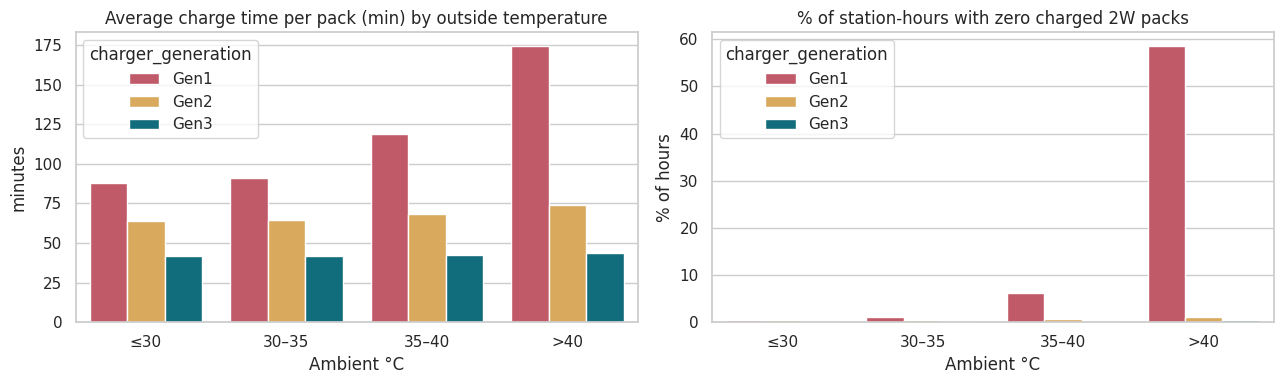

charge_min             stockout          
charger_generation       Gen1  Gen2  Gen3     Gen1 Gen2 Gen3
temp_band                                                   
≤30                     87.99 63.99 42.02     0.01 0.00 0.00
30–35                   91.27 64.56 42.10     0.01 0.01 0.00
35–40                  118.62 68.35 42.77     0.06 0.01 0.00
>40                    174.37 74.18 43.78     0.58 0.01 0.00

In [32]:
ok = hourly[hourly.telemetry_status == 'ok'].merge(stations[['station_id', 'charger_generation', 'city']], on='station_id')
ok['temp_band'] = pd.cut(ok.ambient_temp_c, [-10, 30, 35, 40, 50], labels=['≤30', '30–35', '35–40', '>40'])
ok['stockout_2w'] = ok.charged_2w_min.eq(0)
tele = ok.groupby(['temp_band', 'charger_generation'], observed=True).agg(charge_min=('avg_charge_minutes', 'mean'),
                                                                        stockout=('stockout_2w', 'mean'),
                                                                        cabinet_temp=('cabinet_temp_c', 'mean')).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=tele, x='temp_band', y='charge_min', hue='charger_generation', palette=PALETTE, ax=axes[0])
axes[0].set(title='Average charge time per pack (min) by outside temperature', xlabel='Ambient °C', ylabel='minutes')
sns.barplot(data=tele.assign(stockout=tele.stockout * 100), x='temp_band', y='stockout', hue='charger_generation', palette=PALETTE, ax=axes[1])
axes[1].set(title='% of station-hours with zero charged 2W packs', xlabel='Ambient °C', ylabel='% of hours')
save(fig, '06_thermal_mechanism')
tele.pivot(index='temp_band', columns='charger_generation', values=['charge_min', 'stockout']).round(3)

**This is the mechanism behind the summer failures.** Gen1 cabinets need 88 minutes to charge a pack in normal weather. Above 40°C they need about 174 minutes, and the station has zero charged 2W packs in 58% of those hours. Gen2 slows only slightly and Gen3 not at all. Quarantined packs and power outages are too small to explain the gap: thermal throttling of Gen1 chargers is the bottleneck.

In [33]:
st_perf = swaps.groupby('station_id', observed=True).agg(attempts=('failed', 'size'), fail=('failed', 'mean'))
st_perf = st_perf.join(swaps[swaps.summer].groupby('station_id', observed=True).failed.mean().rename('summer_fail'))
st_perf = st_perf.join(stations.set_index('station_id')[['city', 'zone', 'location_type', 'host_type', 'expansion_wave',
                                                          'charger_generation', 'connectivity_tier', 'slots_2w', 'slots_3w']])
tk = tickets[tickets.station_id.notna()].groupby('station_id').size().rename('tickets')
st_perf = st_perf.join(tk).fillna({'tickets': 0})
st_perf['tickets_per_1k'] = st_perf.tickets / st_perf.attempts * 1000
for col in ['charger_generation', 'location_type', 'host_type', 'connectivity_tier', 'expansion_wave']:
    display(st_perf.groupby(col, observed=True).agg(stations=('fail', 'size'), fail_rate=('fail', 'mean'), summer_fail=('summer_fail', 'mean'),
                                                    tickets_per_1k=('tickets_per_1k', 'mean')).mul([1, 100, 100, 1]).round(2))

,stations,fail_rate,summer_fail,tickets_per_1k
charger_generation,,,,
Gen1,51,7.17,12.83,11.65
Gen2,62,4.88,5.99,9.82
Gen3,37,4.88,5.09,12.03


,stations,fail_rate,summer_fail,tickets_per_1k
location_type,,,,
commercial_hub,44,5.98,9.15,10.78
highway_fuel_pump,21,5.06,6.38,11.77
market,47,5.87,8.61,11.00
residential,21,5.24,7.12,10.87
tech_park,7,5.26,6.87,9.79
transit_hub,10,5.64,7.49,11.28


,stations,fail_rate,summer_fail,tickets_per_1k
host_type,,,,
fuel_retailer,31,5.62,8.08,10.99
kirana,38,5.66,8.15,10.91
mall_parking,44,5.65,8.12,11.03
owned_lot,37,5.69,8.01,11.02


,stations,fail_rate,summer_fail,tickets_per_1k
connectivity_tier,,,,
fair,29,5.79,8.62,11.60
good,98,5.58,7.86,10.79
poor,23,5.84,8.41,11.06


,stations,fail_rate,summer_fail,tickets_per_1k
expansion_wave,,,,
Launch,90,6.14,9.72,10.44
Wave1_2024H2,30,4.91,6.23,11.27
Wave2_2025H1,30,4.96,5.08,12.34


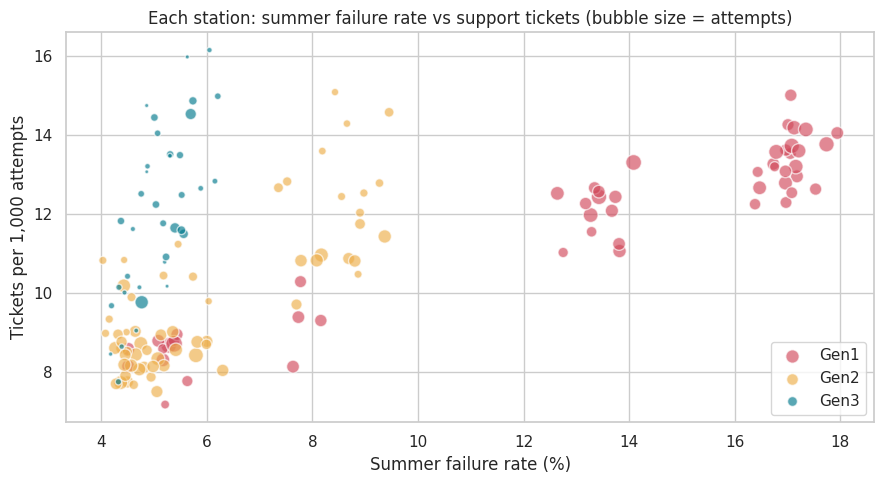

Correlation, station summer failure rate vs tickets per 1k attempts: 0.57


,city,zone,charger_generation,expansion_wave,location_type,attempts,summer_fail
station_id,,,,,,,
STN-DEL-048,Delhi NCR,DEL-West,Gen1,Launch,market,34646,0.18
STN-JAI-138,Jaipur,JAI-Malviya Nagar,Gen1,Launch,market,48945,0.18
STN-JAI-139,Jaipur,JAI-Vaishali,Gen1,Launch,commercial_hub,31659,0.18
STN-JAI-141,Jaipur,JAI-Malviya Nagar,Gen1,Launch,commercial_hub,45594,0.17
STN-JAI-134,Jaipur,JAI-Malviya Nagar,Gen1,Launch,commercial_hub,42925,0.17
STN-DEL-036,Delhi NCR,DEL-Noida,Gen1,Launch,market,35499,0.17
STN-JAI-137,Jaipur,JAI-Malviya Nagar,Gen1,Launch,commercial_hub,44371,0.17
STN-JAI-140,Jaipur,JAI-Malviya Nagar,Gen1,Launch,commercial_hub,44115,0.17
STN-JAI-136,Jaipur,JAI-Malviya Nagar,Gen1,Launch,transit_hub,29340,0.17


In [34]:
fig, ax = plt.subplots(figsize=(9, 5))
for g in ['Gen1', 'Gen2', 'Gen3']:
    d = st_perf[st_perf.charger_generation == g]
    ax.scatter(d.summer_fail * 100, d.tickets_per_1k, s=d.attempts / 400, alpha=.65, color=PALETTE[g], label=g, edgecolor='white')
ax.set(title='Each station: summer failure rate vs support tickets (bubble size = attempts)', xlabel='Summer failure rate (%)', ylabel='Tickets per 1,000 attempts')
ax.legend(); save(fig, '07_station_scatter')
print('Correlation, station summer failure rate vs tickets per 1k attempts:', round(st_perf[['summer_fail', 'tickets_per_1k']].corr().iloc[0, 1], 2))
st_perf.sort_values('summer_fail', ascending=False).head(10)[['city', 'zone', 'charger_generation', 'expansion_wave', 'location_type', 'attempts', 'summer_fail']]

### Did the expansion waves go where riders needed them?

In [35]:
recent = swaps[swaps.event_ts >= '2025-04-01'].groupby('station_id', observed=True).agg(att=('failed', 'size'), fail=('failed', 'mean'))
recent = recent.join(stations.set_index('station_id')[['zone', 'city', 'expansion_wave', 'location_type', 'slots_2w', 'slots_3w']])
recent['swaps_per_slot_day'] = recent.att / 91 / (recent.slots_2w + recent.slots_3w)
display(recent.groupby('expansion_wave').agg(stations=('att', 'size'), fail_Q2_2025=('fail', 'mean'),
                                             swaps_per_slot_day=('swaps_per_slot_day', 'mean')).round(3))
display(pd.crosstab(stations.location_type, stations.expansion_wave))
zone = recent.groupby(['zone', 'expansion_wave']).size().unstack(fill_value=0)
zone['launch_station_fail_Q2_25_%'] = recent[recent.expansion_wave == 'Launch'].groupby('zone').fail.mean() * 100
zone['new_sites'] = zone['Wave1_2024H2'] + zone['Wave2_2025H1']
zone = zone.sort_values('launch_station_fail_Q2_25_%', ascending=False)
zone.round(1).head(12)

,stations,fail_Q2_2025,swaps_per_slot_day
expansion_wave,,,
Launch,90,0.10,5.54
Wave1_2024H2,30,0.06,4.22
Wave2_2025H1,30,0.05,6.22


expansion_wave,Launch,Wave1_2024H2,Wave2_2025H1
location_type,,,
commercial_hub,41,1,4
highway_fuel_pump,2,14,5
market,33,0,14
residential,6,13,2
tech_park,5,1,1
transit_hub,5,1,4


expansion_wave,Launch,Wave1_2024H2,Wave2_2025H1,launch_station_fail_Q2_25_%,new_sites
zone,,,,,
JAI-Malviya Nagar,6,2,2,17.10,4
DEL-South,2,1,0,16.90,1
JAI-Vaishali,4,2,1,16.70,3
DEL-West,4,2,2,15.30,4
DEL-East,4,1,2,14.80,3
DEL-Gurugram-Cyber,3,1,1,14.40,2
DEL-Noida,5,1,0,13.90,1
HYD-South,1,1,0,13.20,1
HYD-West,1,0,2,13.10,2


In [36]:
zz = zone.dropna(subset=['launch_station_fail_Q2_25_%'])
zz['need'] = np.where(zz['launch_station_fail_Q2_25_%'] > 10, 'High-failure zones (>10%)', 'Other zones')
agg = zz.groupby('need').agg(zones=('new_sites', 'size'), launch_stations=('Launch', 'sum'), new_sites=('new_sites', 'sum'))
agg['new_sites_per_launch_station'] = agg.new_sites / agg.launch_stations
agg

,zones,launch_stations,new_sites,new_sites_per_launch_station
need,,,,
High-failure zones (>10%),12,44,28,0.64
Other zones,13,46,29,0.63


**Q3 findings.**

Charger generation dominates every other station attribute. Location type, host type and connectivity differences in failure mostly reflect where Gen1 cabinets happen to sit. Station failure rates and complaint rates move together, so the worst stations also generate the most tickets.

The 20 worst stations in summer 2025 are **all Launch-era Gen1 sites in Delhi NCR and Jaipur**, failing 17–18% of the time.

The expansion waves did not target them. Wave 1 put 27 of its 30 sites at highway fuel pumps and residential locations, which are easier to lease but lower-demand: they have the lowest utilisation of any wave (4.2 swaps per slot per day vs 5.5 at Launch sites). Both waves spread new sites across cities roughly in proportion to existing counts, so the high-failure zones received about as many new sites per existing station as low-failure zones. The waves raised network averages (new Gen2 and Gen3 sites perform well), but left the busiest failing stations untouched.

## 7. Q4 — Battery and equipment performance

In [37]:
bt = batteries.groupby(['cohort', 'pack_type']).agg(packs=('battery_id', 'size'), first_commissioned=('commission_date', 'min'),
                                                    current_soh=('current_soh_pct', 'mean'), soh_lost_per_100_swaps=('soh_lost_per_100_swaps', 'median'),
                                                    wear_inr_per_swap=('wear_inr_per_swap', 'median'), retired=('retired_date', lambda s: s.notna().mean()),
                                                    cost=('purchase_cost_inr', 'mean'))
bt.round(2)

packs first_commissioned  current_soh  soh_lost_per_100_swaps  wear_inr_per_swap  retired      cost
cohort              pack_type                                                                                                     
Amptek              2W_2.1kWh   1098         2024-03-01        79.96                    2.99              24.39     0.00 31,995.05
                    3W_4.8kWh    209         2024-03-01        86.51                    3.34              57.84     0.00 67,822.26
Cellora             2W_2.1kWh   3035         2023-03-01        79.97                    2.98              24.35     0.00 31,983.39
                    3W_4.8kWh    520         2023-03-01        86.52                    3.35              58.15     0.00 67,957.39
Kyron               3W_4.8kWh    177         2024-10-02        86.56                    3.32              57.36     0.00 67,784.90
Kyron KY-2407/08/09 2W_2.1kWh   1385         2024-09-10        60.53                    9.63              78.50     1.00 31,981.68
                    3W_4.8kWh     76         2024-07-01        69.22                    7.90             136.47     0.70 68,237.80

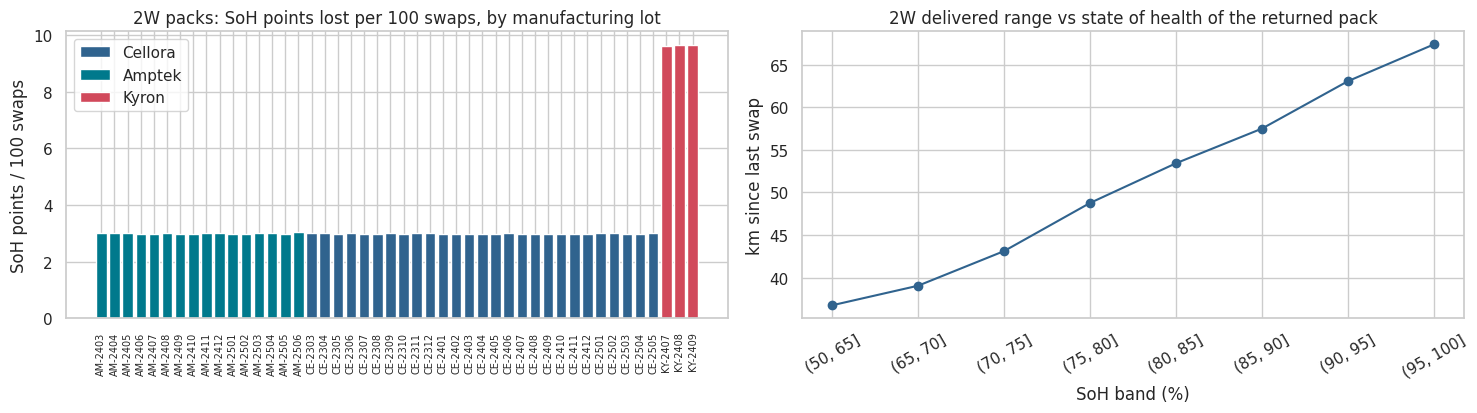

{Interval(50, 65, closed='right'): 36.79999923706055, Interval(65, 70, closed='right'): 39.099998474121094, Interval(70, 75, closed='right'): 43.099998474121094, Interval(75, 80, closed='right'): 48.79999923706055, Interval(80, 85, closed='right'): 53.400001525878906, Interval(85, 90, closed='right'): 57.5, Interval(90, 95, closed='right'): 63.099998474121094, Interval(95, 100, closed='right'): 67.4000015258789}


In [38]:
lot = batteries[batteries.pack_type == '2W_2.1kWh'].groupby(['supplier', 'manufacturing_lot']).agg(
    packs=('battery_id', 'size'), deg=('soh_lost_per_100_swaps', 'median')).reset_index().sort_values('manufacturing_lot')
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
colors = {'Cellora': BLUE, 'Amptek': TEAL, 'Kyron': RED}
axes[0].bar(range(len(lot)), lot.deg, color=[colors[s] for s in lot.supplier])
axes[0].set_xticks(range(len(lot))); axes[0].set_xticklabels(lot.manufacturing_lot, rotation=90, fontsize=7)
axes[0].set(title='2W packs: SoH points lost per 100 swaps, by manufacturing lot', ylabel='SoH points / 100 swaps')
for s_, c in colors.items(): axes[0].bar(0, 0, color=c, label=s_)
axes[0].legend()
rng = comp[comp.vehicle_class == '2W'].copy()
rng['soh_band'] = pd.cut(rng.soh_in_pct, [50, 65, 70, 75, 80, 85, 90, 95, 100])
rb = rng.groupby('soh_band', observed=True).km_since_last_swap.mean()
axes[1].plot(rb.index.astype(str), rb.values, marker='o', color=BLUE)
axes[1].set(title='2W delivered range vs state of health of the returned pack', xlabel='SoH band (%)', ylabel='km since last swap')
axes[1].tick_params(axis='x', rotation=30)
save(fig, '08_battery_cohorts')
print(rb.round(1).to_dict())

In [39]:
# Do riders on degraded packs swap more often? Interval between consecutive completed swaps for the same rider.
seq = comp[['rider_id', 'event_ts', 'soh_out_pct', 'cohort', 'vehicle_class']].sort_values(['rider_id', 'event_ts'])
seq['next_ts'] = seq.groupby('rider_id', observed=True).event_ts.shift(-1)
seq['hours_to_next'] = (seq.next_ts - seq.event_ts).dt.total_seconds() / 3600
seq = seq[(seq.hours_to_next > 0) & (seq.hours_to_next < 72) & (seq.vehicle_class == '2W')]
freq = seq.groupby('cohort').agg(median_hours_to_next_swap=('hours_to_next', 'median'), issued_soh=('soh_out_pct', 'mean'), swaps=('hours_to_next', 'size'))
freq.round(2)

,median_hours_to_next_swap,issued_soh,swaps
cohort,,,
Amptek,21.59,89.48,680632
Cellora,21.58,89.49,1881603
Kyron KY-2407/08/09,18.69,80.65,540844


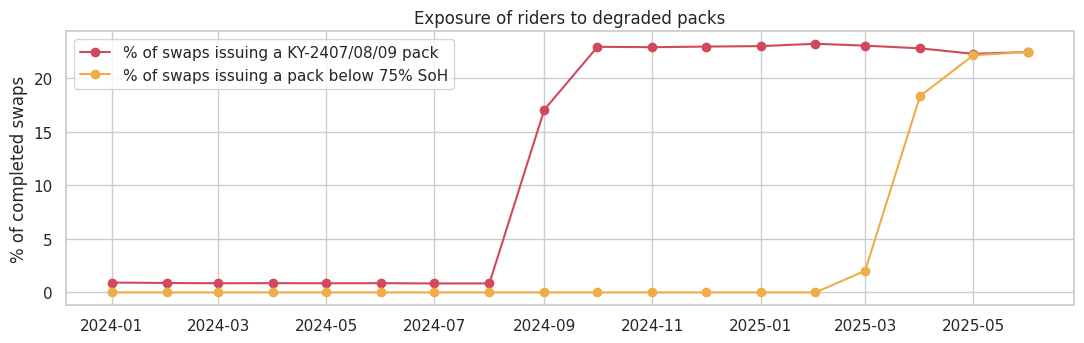

Kyron bad-lot retirements: {'KY-2408': 489, 'KY-2407': 476, 'KY-2409': 473} | retired on <DatetimeArray>
['2025-06-15 00:00:00']
Length: 1, dtype: datetime64[ns]


In [40]:
kyron_share = comp.groupby('month').cohort.apply(lambda s: (s == 'Kyron KY-2407/08/09').mean() * 100)
low_soh = comp.groupby('month').soh_out_pct.apply(lambda s: (s < 75).mean() * 100)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(kyron_share.index, kyron_share, marker='o', color=RED, label='% of swaps issuing a KY-2407/08/09 pack')
ax.plot(low_soh.index, low_soh, marker='o', color=ORANGE, label='% of swaps issuing a pack below 75% SoH')
ax.set(title='Exposure of riders to degraded packs', ylabel='% of completed swaps'); ax.legend()
save(fig, '09_degraded_exposure')
print('Kyron bad-lot retirements:', batteries.loc[batteries.retired_date.notna(), 'manufacturing_lot'].value_counts().to_dict(),
      '| retired on', batteries.retired_date.dropna().unique())

**Q4 findings.**

Three Kyron lots, **KY-2407, KY-2408 and KY-2409** (1,461 2W packs commissioned Jul–Sep 2024, about 22% of the fleet), lose state of health about **3× faster** than every other lot: about 9.6 SoH points per 100 swaps, vs about 3.0 for Cellora, Amptek and later Kyron lots. BMS firmware does not explain it, because all three BMS versions are equally affected within those lots. This is a manufacturing-lot defect, not a supplier-wide or firmware issue.

Delivered range falls steeply with SoH: a 2W pack at 95%+ SoH delivers about 67 km, while one at 60–65% delivers about 37 km, roughly 45% less. Riders on the bad lots swap sooner.

In battery-wear terms, the bad lots cost about 3× more per swap than a normal pack. That is the step-down in margin from September 2024.

About 98% of the three lots were retired as end-of-life on 15 Jun 2025, which removed about 22% of the pack pool in one day and needs backfilling before the next peak. Kyron lots from October 2024 onward look normal.

## 8. Q5 — Pricing and partner economics
### 8.1 Base price change (July 2024)

In [41]:
comp['indep'] = comp.plan_type != 'partner_billed'
lp = comp[comp.tariff_code == 'STD'].groupby(['month', 'vehicle_class'], observed=True).list_price_inr.median().unstack()
print('Standard list price by month:'); display(lp.loc[['2024-06-01', '2024-07-01']])
ind = comp[comp.indep].groupby('month').agg(swaps=('revenue', 'size'), riders=('rider_id', 'nunique'), rev=('revenue', 'mean'))
ind['swaps_per_active_rider'] = ind.swaps / ind.riders
pre, post = ind.loc['2024-04':'2024-06'], ind.loc['2024-07':'2024-09']
print(f"Independent riders: revenue/swap {pre.rev.mean():.1f} → {post.rev.mean():.1f}; swaps per active rider/month "
      f"{pre.swaps_per_active_rider.mean():.1f} → {post.swaps_per_active_rider.mean():.1f}")

Standard list price by month:


vehicle_class,2W,3W
month,,
2024-06-01,60.00,100.00
2024-07-01,65.00,110.00


Independent riders: revenue/swap 62.2 → 67.4; swaps per active rider/month 20.2 → 21.7


The base price rose from ₹60 to ₹65 (2W) and from ₹100 to ₹110 (3W) on 1 July 2024. Revenue per swap rose by about 8.5%, and usage per active independent rider did not fall. The rise was absorbed without visible demand loss.

### 8.2 Peak / off-peak pilot (Bengaluru and Pune from Oct 2024): difference-in-differences

In [42]:
print('Pilot tariff hours (corrected time):')
display(comp[comp.tariff_code.isin(['PEAK', 'OFFPEAK'])].groupby(['tariff_code', 'hour'], observed=True).size().unstack(0).fillna(0).astype(int).T)
print('Median charged amount by tariff (2W list ₹65):', comp[comp.list_price_inr == 65].groupby('tariff_code', observed=True).revenue.median().to_dict())

Pilot tariff hours (corrected time):


hour,0,1,2,3,4,5,12,13,14,15,16,18,19,20,21,22,23
tariff_code,,,,,,,,,,,,,,,,,
OFFPEAK,1939,1907,2004,1989,3356,3267,0,0,4825,6224,6127,2,4,4,2,4,3179
PEAK,0,0,0,0,0,0,28189,28266,0,0,0,0,37505,37247,27856,4859,0


Median charged amount by tariff (2W list ₹65): {'OFFPEAK': 57.0, 'PARTNER': 57.849998474121094, 'PEAK': 80.0, 'STD': 65.0}


In [43]:
PEAK_H = [12, 13, 19, 20, 21]
comp['peak_hour'] = comp.hour.isin(PEAK_H)
comp['pilot_city'] = comp.city.isin(['Bengaluru', 'Pune'])
comp['post_pilot'] = comp.event_ts >= '2024-10-01'
comp['surcharge_flag'] = comp.partner_id.astype(str).map(partners.set_index('partner_id').peak_surcharge_billable)
comp['segment'] = np.select([comp.indep, comp.surcharge_flag.eq('Y'), comp.surcharge_flag.eq('N')],
                            ['Independent (pays surcharge)', 'Partner, surcharge billable (Y)', 'Partner, not billable (N)'], 'other')

def did(df, y='peak_hour'):
    t = df.groupby(['pilot_city', 'post_pilot'])[y].mean() * 100
    return (t[(True, True)] - t[(True, False)]) - (t[(False, True)] - t[(False, False)]), t

rows = []
for seg_name, d in comp.groupby('segment'):
    est, t = did(d)
    # regression version with clustered SEs by station for inference
    dd = d[['peak_hour', 'pilot_city', 'post_pilot', 'station_id']].sample(min(len(d), 400_000), random_state=1)
    dd = dd.assign(y=dd.peak_hour.astype(int), P=dd.pilot_city.astype(int), T=dd.post_pilot.astype(int))
    r = smf.ols('y ~ P * T', data=dd).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(dd.station_id.astype(str))[0]})
    rows.append({'segment': seg_name, 'pilot_pre_%': t[(True, False)], 'pilot_post_%': t[(True, True)],
                 'control_pre_%': t[(False, False)], 'control_post_%': t[(False, True)], 'DiD_pp': est,
                 'ci_low': r.conf_int().loc['P:T', 0] * 100, 'ci_high': r.conf_int().loc['P:T', 1] * 100})
did_tbl = pd.DataFrame(rows).set_index('segment'); did_tbl.round(2)

,pilot_pre_%,pilot_post_%,control_pre_%,control_post_%,DiD_pp,ci_low,ci_high
segment,,,,,,,
Independent (pays surcharge),60.00,57.46,59.59,59.59,-2.53,-3.08,-1.75
"Partner, not billable (N)",64.81,64.04,64.52,64.54,-0.79,-1.50,-0.25
"Partner, surcharge billable (Y)",43.60,40.48,40.89,41.76,-4.00,-5.81,-3.39


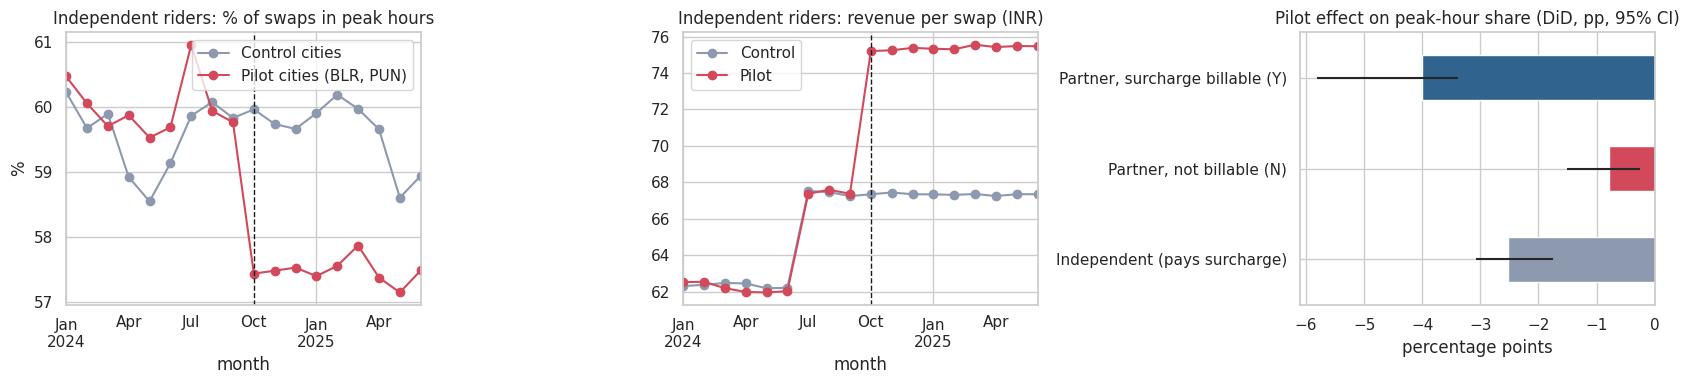

In [44]:
pk = comp[comp.indep].groupby(['month', 'pilot_city']).peak_hour.mean().unstack() * 100
rv = comp[comp.indep].groupby(['month', 'pilot_city']).revenue.mean().unstack()
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
pk.plot(ax=axes[0], marker='o', color=[GREY, RED]); axes[0].legend(['Control cities', 'Pilot cities (BLR, PUN)'])
axes[0].axvline(pd.Timestamp('2024-10-01'), ls='--', color='k', lw=1); axes[0].set(title='Independent riders: % of swaps in peak hours', ylabel='%')
rv.plot(ax=axes[1], marker='o', color=[GREY, RED]); axes[1].legend(['Control', 'Pilot'])
axes[1].axvline(pd.Timestamp('2024-10-01'), ls='--', color='k', lw=1); axes[1].set(title='Independent riders: revenue per swap (INR)')
did_tbl['DiD_pp'].plot.barh(ax=axes[2], color=[GREY, RED, BLUE], xerr=[did_tbl.DiD_pp - did_tbl.ci_low, did_tbl.ci_high - did_tbl.DiD_pp])
axes[2].axvline(0, color='k', lw=.8); axes[2].set(title='Pilot effect on peak-hour share (DiD, pp, 95% CI)', xlabel='percentage points', ylabel='')
save(fig, '10_pricing_pilot')

**Pilot findings.**

Riders who actually pay the surcharge, both independents and the partners whose contracts make it billable, moved about 2.5–4 percentage points of their swaps out of the peak window, relative to control cities. Independent riders' revenue per swap rose by about ₹8 (+12%).

Riders of partners who are **not** billed for peak (ZipDrop and Swiggle Go) did not shift at all. Yet they have the most peak-heavy usage on the network (about 64% of swaps in peak hours, vs about 41% for billable partners).

The pilot works modestly on the riders it reaches. Its reach is limited by contract terms, not rider behaviour.

### 8.3 Fleet partner economics

In [45]:
pe = comp.groupby('partner').agg(swaps=('revenue', 'size'), revenue_inr_m=('revenue', lambda s: s.sum() / 1e6), rev_per_swap=('revenue', 'mean'),
                                  energy=('energy_cost', 'mean'), wear=('wear_cost', 'mean'), station=('station_cost', 'mean'),
                                  cm1_per_swap=('cm1', 'mean'), cm2_per_swap=('cm2', 'mean'), cm2_total_inr_m=('cm2', lambda s: s.sum() / 1e6),
                                  peak_share=('peak_hour', 'mean'))
pe = pe.join(partners.set_index('partner_id')[['partner_name', 'partner_segment', 'discount_pct', 'discount_pct_after_amendment',
                                               'peak_surcharge_billable', 'payment_terms_days']])
pe['partner_name'] = pe.partner_name.fillna('Independent riders')
pe = pe.sort_values('revenue_inr_m', ascending=False)
pe.round(2)

,swaps,revenue_inr_m,rev_per_swap,energy,wear,station,cm1_per_swap,cm2_per_swap,cm2_total_inr_m,peak_share,partner_name,partner_segment,discount_pct,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days
partner,,,,,,,,,,,,,,,,
Independent,1218521,83.12,68.21,18.17,35.48,13.48,14.56,1.08,1.32,0.59,Independent riders,NaN,NaN,NaN,NaN,NaN
FP-01,516367,32.03,62.03,18.21,35.31,13.44,8.50,-4.93,-2.55,0.66,FeastFly,food_delivery,10.00,NaN,Y,30.00
FP-03,549390,28.61,52.07,19.14,35.50,12.84,-2.57,-15.42,-8.47,0.64,ZipDrop,quick_commerce,12.00,28.00,N,45.00
FP-02,296209,16.74,56.51,18.13,35.55,13.52,2.84,-10.68,-3.16,0.20,ParcelNest,ecom_logistics,15.00,NaN,Y,30.00
FP-05,237632,14.09,59.30,18.36,35.30,13.55,5.64,-7.91,-1.88,0.66,Swiggle Go,food_delivery,11.00,NaN,N,30.00
FP-04,131334,13.06,99.46,40.80,64.06,13.78,-5.40,-19.18,-2.52,0.17,CargoTuk,cargo_3w,8.00,NaN,Y,30.00
FP-07,127961,7.93,62.01,17.89,34.61,13.66,9.52,-4.15,-0.53,0.63,QuickCart,quick_commerce,9.00,NaN,Y,30.00
FP-06,119503,7.49,62.71,17.94,35.32,13.83,9.46,-4.37,-0.52,0.26,RideMitra,bike_taxi,6.00,NaN,Y,15.00
FP-08,92027,5.85,63.61,18.06,35.60,13.21,9.95,-3.25,-0.30,0.66,DabbaXpress,food_delivery,8.00,NaN,Y,30.00


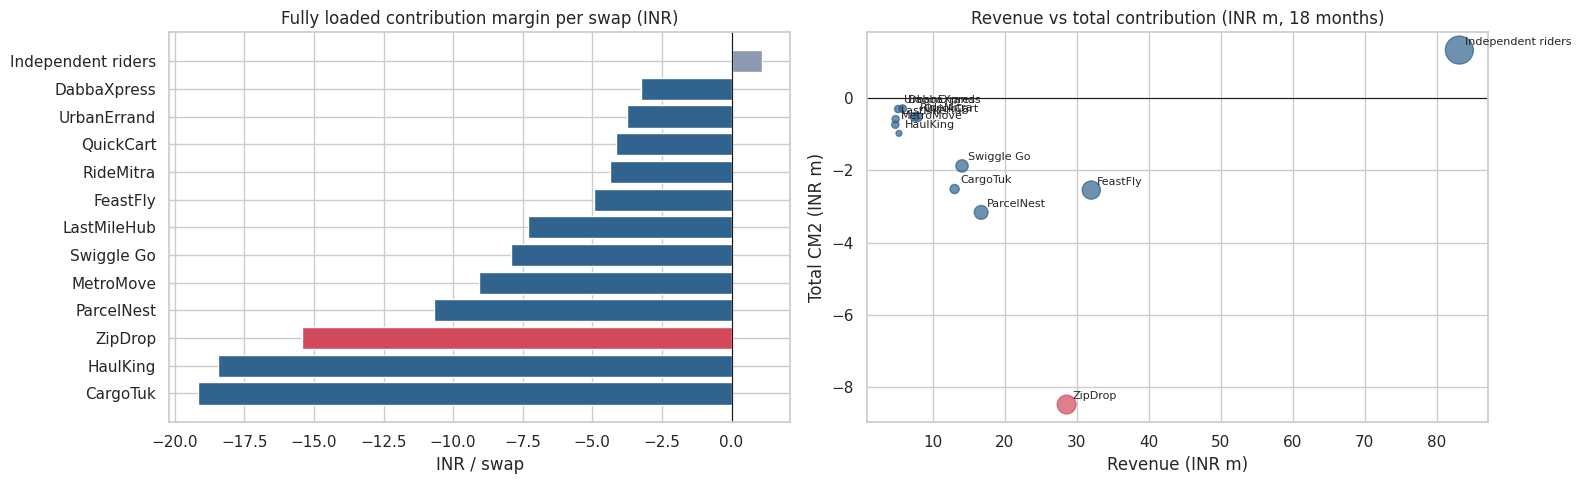

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
p2 = pe.sort_values('cm2_per_swap')
cols = [RED if n == 'ZipDrop' else (GREY if n == 'Independent riders' else BLUE) for n in p2.partner_name]
axes[0].barh(p2.partner_name, p2.cm2_per_swap, color=cols); axes[0].axvline(0, color='k', lw=.8)
axes[0].set(title='Fully loaded contribution margin per swap (INR)', xlabel='INR / swap')
axes[1].scatter(pe.revenue_inr_m, pe.cm2_total_inr_m, s=pe.swaps / 3000, color=[RED if n == 'ZipDrop' else BLUE for n in pe.partner_name], alpha=.7)
for _, r in pe.iterrows(): axes[1].annotate(r.partner_name, (r.revenue_inr_m, r.cm2_total_inr_m), fontsize=8, xytext=(4, 4), textcoords='offset points')
axes[1].axhline(0, color='k', lw=.8); axes[1].set(title='Revenue vs total contribution (INR m, 18 months)', xlabel='Revenue (INR m)', ylabel='Total CM2 (INR m)')
save(fig, '11_partner_economics')

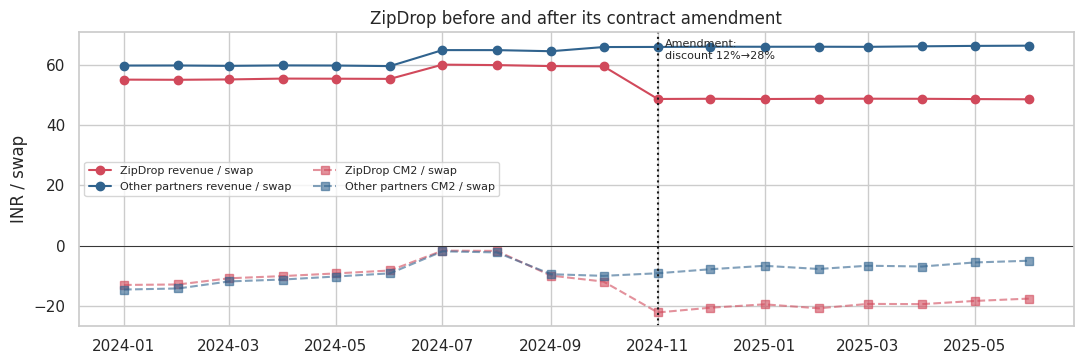

ZipDrop rev/swap before vs after: 59.7 → 48.6


In [47]:
zd = comp[comp.partner == 'FP-03'].groupby('month')[['revenue', 'cm1', 'cm2']].mean()
others = comp[(comp.partner != 'FP-03') & (comp.partner != 'Independent')].groupby('month')[['revenue', 'cm2']].mean()
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(zd.index, zd.revenue, marker='o', color=RED, label='ZipDrop revenue / swap')
ax.plot(others.index, others.revenue, marker='o', color=BLUE, label='Other partners revenue / swap')
ax.plot(zd.index, zd.cm2, marker='s', ls='--', color=RED, alpha=.6, label='ZipDrop CM2 / swap')
ax.plot(others.index, others.cm2, marker='s', ls='--', color=BLUE, alpha=.6, label='Other partners CM2 / swap')
ax.axvline(pd.Timestamp('2024-11-01'), ls=':', color='k'); ax.text(pd.Timestamp('2024-11-05'), 62, 'Amendment:\ndiscount 12%→28%', fontsize=8)
ax.axhline(0, color='k', lw=.6); ax.set(title='ZipDrop before and after its contract amendment', ylabel='INR / swap'); ax.legend(fontsize=8, ncol=2)
save(fig, '12_zipdrop_amendment')
print('ZipDrop rev/swap before vs after:', round(zd.loc[:'2024-10', 'revenue'].loc['2024-07':].mean(), 1), '→', round(zd.loc['2024-11':, 'revenue'].mean(), 1))

In [48]:
# Sensitivity: does the partner ranking survive a different wear assumption?
sens = {}
for retire in [50, 60, 70]:
    w = batteries.purchase_cost_inr * (batteries.soh_lost / batteries.swaps_issued.replace(0, np.nan)) / (batteries.initial_soh_pct - retire)
    wear_alt = comp.battery_id.map(dict(zip(batteries.battery_id, w)))
    sens[f'retire at {retire}% SoH'] = (comp.revenue - comp.energy_cost - wear_alt - comp.station_cost).groupby(comp.partner).mean()
sens = pd.DataFrame(sens).join(pe.partner_name).set_index('partner_name').sort_values('retire at 60% SoH')
sens.round(1)

,retire at 50% SoH,retire at 60% SoH,retire at 70% SoH
partner_name,,,
CargoTuk,-6.20,-19.20,-41.10
HaulKing,-5.40,-18.50,-40.40
ZipDrop,-8.20,-15.40,-27.60
ParcelNest,-3.50,-10.70,-22.90
MetroMove,-1.70,-9.10,-21.40
Swiggle Go,-0.70,-7.90,-20.00
LastMileHub,0.10,-7.30,-19.80
FeastFly,2.20,-4.90,-17.00
RideMitra,2.80,-4.40,-16.50


**Partner findings.**

**ZipDrop is the largest partner by swaps, but the least valuable.** After its November 2024 amendment (discount 12% → 28%), revenue per swap fell from about ₹60 to about ₹49. That is about ₹11 below other 2W partners, on the same energy, wear and station costs. ZipDrop also has 64% of its swaps in peak hours, pays no peak surcharge and has the longest payment terms (45 days). Over 18 months it generated the largest negative total contribution of any customer.

The 3W cargo partners (CargoTuk, HaulKing) are also loss-making per swap, because 4.8 kWh packs cost twice as much in energy and wear while the price is not twice as high.

The best partners (DabbaXpress, UrbanErrand, QuickCart, RideMitra) are near break-even on a fully loaded basis.

The ranking is unchanged whether packs are assumed to be retired at 50%, 60% or 70% SoH.

## 9. Q6 — Root cause analysis of new-rider retention

**Definitions.** A *new rider* signed up on or after 1 Jan 2024. Their first attempt starts a 60-day observation window, and only riders with a full 60 days of follow-up are kept, which avoids right-censoring. A rider **churned** if they made **no attempt in days 30–59** after their first attempt. Explanatory features describe only the **first 14 days**, so they come before the outcome.

In [49]:
new = swaps[swaps.signup_date >= '2024-01-01']
first = new.groupby('rider_id', observed=True).event_ts.min().rename('first_ts')
eligible = first[first + pd.Timedelta(days=60) <= pd.Timestamp('2025-06-30 23:59:59')]
new = new[new.rider_id.isin(eligible.index)].merge(eligible, left_on='rider_id', right_index=True)
new['day'] = (new.event_ts - new.first_ts).dt.days
returned = set(new.loc[(new.day >= 30) & (new.day < 60), 'rider_id'])
e14 = new[new.day < 14].copy()
e14['long_wait'] = e14.queue_wait_sec > 600
e14['low_soh_pack'] = (e14.soh_out_pct < 80).where(e14.completed)
e14['bad_lot_pack'] = e14.battery_out_id.astype(str).isin(set(batteries.loc[batteries.manufacturing_lot.isin(BAD_LOTS), 'battery_id'])).where(e14.completed).astype(float)
e14['peak_tariff'] = e14.tariff_code.astype(str).eq('PEAK')
e14 = e14.sort_values('event_ts')
e14['n'] = e14.groupby('rider_id', observed=True).cumcount()
feat = e14.groupby('rider_id', observed=True).agg(attempts_14d=('failed', 'size'), fail_rate_14d=('failed', 'mean'),
                                                  n_no_battery=('no_battery', 'sum'), n_abandoned=('abandoned', 'sum'),
                                                  long_wait_share=('long_wait', 'mean'), mean_soh_issued=('soh_out_pct', 'mean'),
                                                  low_soh_share=('low_soh_pack', 'mean'), bad_lot_share=('bad_lot_pack', 'mean'),
                                                  median_km=('km_since_last_swap', 'median'), peak_tariff_share=('peak_tariff', 'mean'),
                                                  first_station=('station_id', 'first'), city=('city', 'first'), first_gen=('charger_generation', 'first'))
feat['fails_first3'] = e14[e14.n < 3].groupby('rider_id', observed=True).failed.sum()
feat = feat.join(eligible)
feat['churned'] = (~feat.index.isin(returned)).astype(int)
feat = feat.join(riders.set_index('rider_id')[['partner_id', 'vehicle_class', 'plan_type', 'signup_channel', 'kyc_verified']])
comp_since = feat.first_station.astype(str).map(stations.set_index('station_id').competitor_within_1_5km_since)
feat['competitor_nearby'] = (comp_since <= feat.first_ts).astype(int)
feat['cohort'] = feat.first_ts.dt.to_period('M').astype(str)
feat['summer_start'] = feat.first_ts.dt.month.isin([4, 5, 6]).astype(int)
feat['zipdrop'] = (feat.partner_id == 'FP-03').astype(int)
feat['pilot_price_exposed'] = (feat.city.isin(['Bengaluru', 'Pune']) & (feat.first_ts >= '2024-10-01') & (feat.plan_type != 'partner_billed')).astype(int)
tk14 = tickets.merge(feat[['first_ts']], left_on='rider_id', right_index=True)
tk14 = tk14[(tk14.created_ts >= tk14.first_ts) & (tk14.created_ts < tk14.first_ts + pd.Timedelta(days=14))]
feat['tickets_14d'] = feat.index.map(tk14.groupby('rider_id').size()).fillna(0)
print(f'New riders analysed: {len(feat):,}  |  30-60 day churn rate: {feat.churned.mean():.1%}')

New riders analysed: 13,844  |  30-60 day churn rate: 14.6%


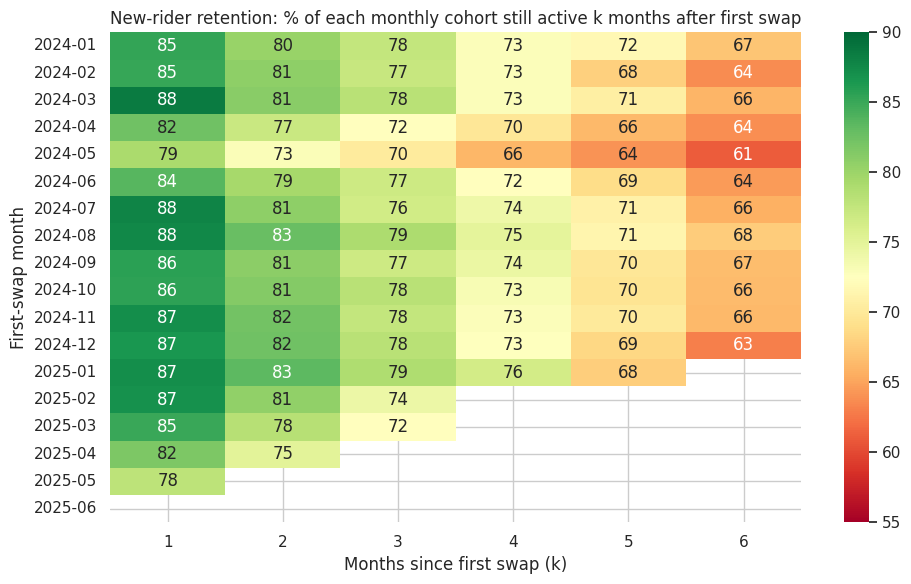

In [50]:
# Cohort retention curves (share of each monthly cohort active in month k after first attempt)
new_all = swaps[swaps.signup_date >= '2024-01-01']
fa = new_all.groupby('rider_id', observed=True).event_ts.min()
act = new_all[['rider_id', 'event_ts']].merge(fa.rename('f'), left_on='rider_id', right_index=True)
act['k'] = ((act.event_ts - act.f).dt.days // 30).astype(int)
act = act[act.k <= 6].drop_duplicates(['rider_id', 'k'])
act['cohort'] = act.f.dt.to_period('M')
size = fa.dt.to_period('M').value_counts()
ret = act.groupby(['cohort', 'k']).size().unstack().div(size, axis=0)
horizon = (pd.Timestamp('2025-06-30') - ret.index.to_timestamp()).days // 30   # mask incomplete cells
for k in ret.columns: ret.loc[horizon < k + 1, k] = np.nan
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ret.iloc[:, 1:] * 100, annot=True, fmt='.0f', cmap='RdYlGn', vmin=55, vmax=90, ax=ax)
ax.set(title='New-rider retention: % of each monthly cohort still active k months after first swap', xlabel='Months since first swap (k)', ylabel='First-swap month')
save(fig, '13_cohort_retention')

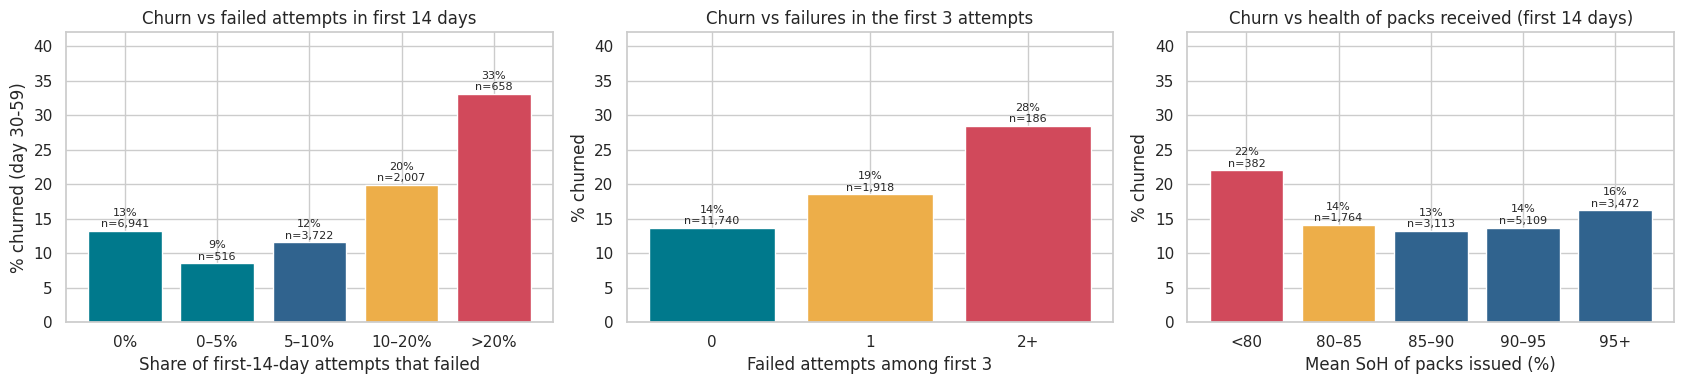

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
b1 = feat.groupby(pd.cut(feat.fail_rate_14d, [-.01, 0, .05, .1, .2, 1], labels=['0%', '0–5%', '5–10%', '10–20%', '>20%']), observed=True).churned.agg(['mean', 'size'])
axes[0].bar(b1.index.astype(str), b1['mean'] * 100, color=[TEAL, TEAL, BLUE, ORANGE, RED])
for i, (m_, n_) in enumerate(zip(b1['mean'], b1['size'])): axes[0].text(i, m_ * 100 + .5, f'{m_:.0%}\nn={n_:,}', ha='center', fontsize=8)
axes[0].set(title='Churn vs failed attempts in first 14 days', xlabel='Share of first-14-day attempts that failed', ylabel='% churned (day 30-59)')
b2 = feat.groupby(feat.fails_first3.clip(upper=2)).churned.agg(['mean', 'size'])
axes[1].bar(['0', '1', '2+'], b2['mean'] * 100, color=[TEAL, ORANGE, RED])
for i, (m_, n_) in enumerate(zip(b2['mean'], b2['size'])): axes[1].text(i, m_ * 100 + .5, f'{m_:.0%}\nn={n_:,}', ha='center', fontsize=8)
axes[1].set(title='Churn vs failures in the first 3 attempts', xlabel='Failed attempts among first 3', ylabel='% churned')
b3 = feat.groupby(pd.cut(feat.mean_soh_issued, [0, 80, 85, 90, 95, 101], labels=['<80', '80–85', '85–90', '90–95', '95+']), observed=True).churned.agg(['mean', 'size'])
axes[2].bar(b3.index.astype(str), b3['mean'] * 100, color=[RED, ORANGE, BLUE, BLUE, BLUE])
for i, (m_, n_) in enumerate(zip(b3['mean'], b3['size'])): axes[2].text(i, m_ * 100 + .5, f'{m_:.0%}\nn={n_:,}', ha='center', fontsize=8)
axes[2].set(title='Churn vs health of packs received (first 14 days)', xlabel='Mean SoH of packs issued (%)', ylabel='% churned')
for a in axes: a.set_ylim(0, 42)
save(fig, '14_churn_dose_response')

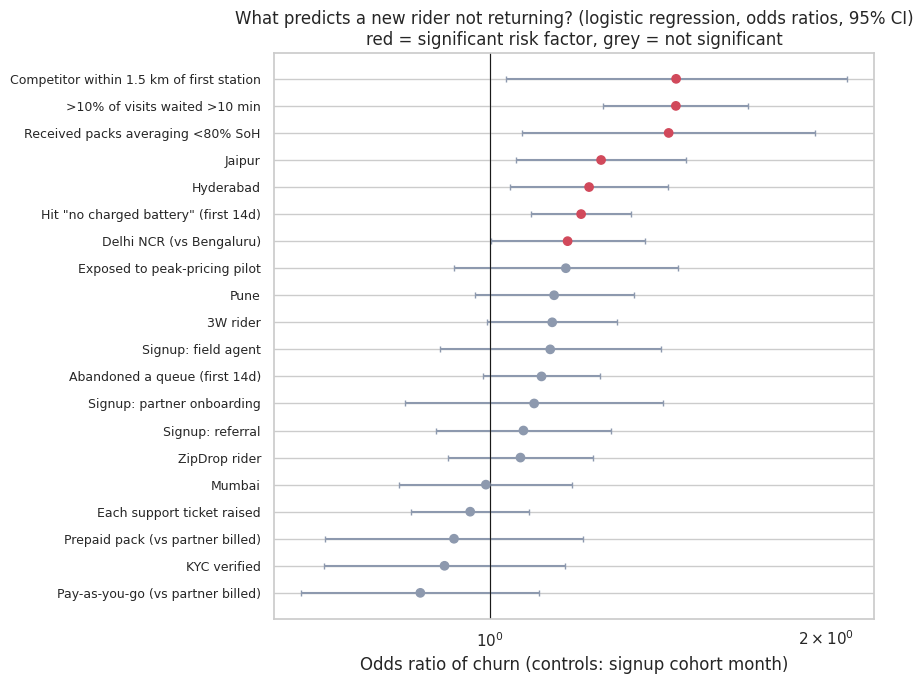

,odds_ratio,ci_low,ci_high,p_value
Pay-as-you-go (vs partner billed),0.87,0.68,1.11,0.25
KYC verified,0.91,0.71,1.17,0.46
Prepaid pack (vs partner billed),0.93,0.71,1.21,0.58
Each support ticket raised,0.96,0.85,1.08,0.51
Mumbai,0.99,0.83,1.19,0.93
ZipDrop rider,1.06,0.92,1.24,0.41
Signup: referral,1.07,0.89,1.28,0.46
Signup: partner onboarding,1.09,0.84,1.43,0.50
Abandoned a queue (first 14d),1.11,0.99,1.25,0.08
Signup: field agent,1.13,0.90,1.42,0.28


In [52]:
feat['any_no_battery'] = (feat.n_no_battery > 0).astype(int)
feat['any_abandoned'] = (feat.n_abandoned > 0).astype(int)
feat['high_long_wait'] = (feat.long_wait_share > .10).astype(int)
feat['low_soh_packs'] = (feat.mean_soh_issued < 80).astype(int)
feat['short_range'] = (feat.median_km < 45).astype(int)
feat['vc'] = feat.vehicle_class
formula = ('churned ~ any_no_battery + any_abandoned + high_long_wait + low_soh_packs + competitor_nearby + zipdrop + '
           'pilot_price_exposed + tickets_14d + C(vc) + C(plan_type) + C(city) + C(signup_channel) + C(kyc_verified) + C(cohort)')
logit = smf.logit(formula, data=feat.dropna(subset=['mean_soh_issued'])).fit(disp=0, cov_type='HC1')
res = pd.DataFrame({'odds_ratio': np.exp(logit.params), 'ci_low': np.exp(logit.conf_int()[0]), 'ci_high': np.exp(logit.conf_int()[1]), 'p_value': logit.pvalues})
res = res[~res.index.str.contains('cohort|Intercept')]
labels = {'any_no_battery': 'Hit "no charged battery" (first 14d)', 'any_abandoned': 'Abandoned a queue (first 14d)',
          'high_long_wait': '>10% of visits waited >10 min', 'low_soh_packs': 'Received packs averaging <80% SoH',
          'competitor_nearby': 'Competitor within 1.5 km of first station', 'zipdrop': 'ZipDrop rider',
          'pilot_price_exposed': 'Exposed to peak-pricing pilot', 'tickets_14d': 'Each support ticket raised',
          'C(vc)[T.3W]': '3W rider', 'C(plan_type)[T.pay_as_you_go]': 'Pay-as-you-go (vs partner billed)',
          'C(plan_type)[T.prepaid_pack]': 'Prepaid pack (vs partner billed)', 'C(city)[T.Delhi NCR]': 'Delhi NCR (vs Bengaluru)',
          'C(city)[T.Hyderabad]': 'Hyderabad', 'C(city)[T.Jaipur]': 'Jaipur', 'C(city)[T.Mumbai]': 'Mumbai', 'C(city)[T.Pune]': 'Pune',
          'C(signup_channel)[T.field_agent]': 'Signup: field agent', 'C(signup_channel)[T.partner_onboarding]': 'Signup: partner onboarding',
          'C(signup_channel)[T.referral]': 'Signup: referral', 'C(kyc_verified)[T.True]': 'KYC verified'}
res.index = res.index.map(lambda x: labels.get(x, x))
res = res.sort_values('odds_ratio')
fig, ax = plt.subplots(figsize=(9, 7))
colors_ = [RED if (p < .05 and o > 1) else (TEAL if (p < .05 and o < 1) else GREY) for o, p in zip(res.odds_ratio, res.p_value)]
ax.errorbar(res.odds_ratio, range(len(res)), xerr=[res.odds_ratio - res.ci_low, res.ci_high - res.odds_ratio], fmt='none', ecolor=GREY, capsize=2)
ax.scatter(res.odds_ratio, range(len(res)), color=colors_, zorder=3)
ax.set_yticks(range(len(res))); ax.set_yticklabels(res.index, fontsize=9); ax.axvline(1, color='k', lw=.8)
ax.set(title='What predicts a new rider not returning? (logistic regression, odds ratios, 95% CI)\nred = significant risk factor, grey = not significant',
       xlabel='Odds ratio of churn (controls: signup cohort month)'); ax.set_xscale('log')
save(fig, '15_churn_drivers')
res.round(3)

**How to read this.** The model includes cohort-month dummies, so the effects are compared among riders who started in the same month. That removes seasonality and network-growth effects. Tickets raised are *protective*: riders who complain are more engaged, so complaint volume is not a churn signal on its own.

In [53]:
# Attributable churn: how much churn would disappear if first-14-day failures were at the off-season baseline?
base = feat[feat.fail_rate_14d <= .05].churned.mean()
excess = (feat.churned - base).clip(lower=0)[feat.fail_rate_14d > .10].sum()
print(f'Churn among riders with ≤5% early failures: {base:.1%}')
print(f'Riders with >10% early failures: {(feat.fail_rate_14d > .10).mean():.1%} of new riders, churn {feat[feat.fail_rate_14d > .10].churned.mean():.1%}')
print(f'Excess churners attributable to high early failure: ~{excess:,.0f} of {feat.churned.sum():,} churners ({excess / feat.churned.sum():.0%})')
print('Summer vs other starters:', feat.groupby('summer_start').churned.mean().round(3).to_dict())
print('Hot-city Gen1 first station vs others:', feat.groupby(feat.city.isin(['Delhi NCR', 'Jaipur', 'Hyderabad']) & feat.first_gen.eq('Gen1')).churned.mean().round(3).to_dict())

Churn among riders with ≤5% early failures: 12.9%
Riders with >10% early failures: 19.3% of new riders, churn 23.2%
Excess churners attributable to high early failure: ~538 of 2,015 churners (27%)
Summer vs other starters: {0: 0.134, 1: 0.182}
Hot-city Gen1 first station vs others: {False: 0.137, True: 0.161}


**Q6 findings: primary vs secondary drivers of early churn.**

| Tier | Factor | Evidence |
|---|---|---|
| **Primary** | **Failed swaps in the first two weeks** (no charged battery, abandoned queue, long waits) | Clear dose-response. Churn is about 13% with no early failures, 22% at 10–20% failed attempts, and 36% above 20%. Two failures in the first three attempts means 29% churn vs 14%. It stays significant with cohort controls. Riders who start in summer churn more (about 19% vs 13%). |
| **Primary** | **Receiving degraded packs** (low SoH, short range) | Riders whose early packs averaged below 80% SoH churn at about 22% vs about 14%. Range complaints are the largest and fastest-growing ticket theme (section 10). |
| Secondary / contributing | Competitor opening within 1.5 km | Higher odds, but based on only about 240 riders, so the estimate is wide. Worth monitoring. |
| Secondary / contributing | City (Delhi NCR, Jaipur, Hyderabad) | Elevated churn, largely *through* the failure channel above. |
| Not supported | Plan type, peak-pricing exposure, ZipDrop affiliation, signup channel, KYC | No significant effect after controls. **Price is not why new riders leave; reliability is.** |

The model's overall explanatory power is modest (churn among gig riders is noisy and has many causes outside the data), so these are associations, not proof. However, the direction, the dose-response and the timing (the features come before the outcome) are consistent with failures and degraded packs being the main controllable drivers.

## 10. Deep dives
### 10.1 Support-ticket text: what the categories miss

In [54]:
def theme(text):
    t = str(text).lower()
    if re.search(r'range|rnage|discharge fast|scooter dying|weak|bike problem|vehicle performance', t): return 'Range / battery health'
    if re.search(r'no batt|no battry|charged batt|charged battry|empty sta|sab batteries', t): return 'No charged battery'
    if re.search(r'queue|line thi|waited', t): return 'Long queue'
    if re.search(r'surcharge', t): return 'Billing: surprise surcharge'
    if re.search(r'amount|charged extra', t): return 'Billing: wrong amount'
    if re.search(r'app|qr', t): return 'App / QR'
    return 'Unclear'
tickets['text_theme'] = tickets.rider_comment.map(theme)
print('Unique comment strings:', tickets.rider_comment.nunique())
display(pd.crosstab(tickets.text_theme, tickets.category, margins=True))

Unique comment strings: 89


category,app_issue,billing_dispute,long_queue,low_range,no_battery_available,other,All
text_theme,,,,,,,
App / QR,5787,0,0,0,0,0,5787
Billing: surprise surcharge,0,1559,0,0,0,0,1559
Billing: wrong amount,0,3156,0,0,0,0,3156
Long queue,0,0,5731,0,0,0,5731
No charged battery,0,0,0,0,11647,0,11647
Range / battery health,0,0,0,6636,0,9484,16120
All,5787,4715,5731,6636,11647,9484,44000


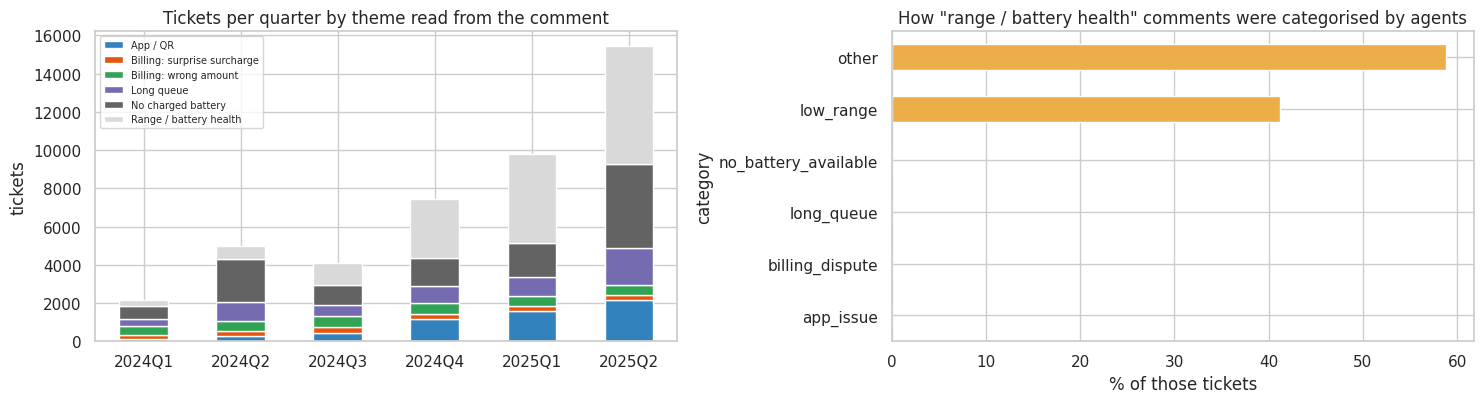

Share of tickets citing a KY-2407/08/09 pack, by theme:


,bad
text_theme,
App / QR,33.00
Billing: surprise surcharge,10.10
Billing: wrong amount,10.10
Long queue,22.40
No charged battery,21.10
Range / battery health,33.60


Distances quoted in "scooter dying at X km" comments: {'count': 1365.0, 'mean': 50.9, 'std': 8.5, 'min': -10.0, '25%': 46.0, '50%': 52.0, '75%': 56.0, 'max': 105.0}


In [55]:
tw = tickets[tickets.in_window]
qt = pd.crosstab(tw.created_ts.dt.to_period('Q'), tw.text_theme)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
qt.plot.bar(stacked=True, ax=axes[0], colormap='tab20c', rot=0); axes[0].set(title='Tickets per quarter by theme read from the comment', xlabel='', ylabel='tickets'); axes[0].legend(fontsize=7)
lab = tickets.groupby('text_theme').category.value_counts(normalize=True).unstack().fillna(0) * 100
lab.loc[['Range / battery health']].T.sort_values('Range / battery health').plot.barh(ax=axes[1], color=ORANGE, legend=False)
axes[1].set(title='How "range / battery health" comments were categorised by agents', xlabel='% of those tickets')
save(fig, '16_ticket_text')
kb = tickets[tickets.battery_id.notna()].assign(bad=lambda d: d.battery_id.isin(batteries.loc[batteries.manufacturing_lot.isin(BAD_LOTS), 'battery_id']))
print('Share of tickets citing a KY-2407/08/09 pack, by theme:'); display(kb.groupby('text_theme').bad.mean().mul(100).round(1))
dist = tickets.rider_comment.str.extract(r'dying at (-?\d+) km')[0].astype(float)
print('Distances quoted in "scooter dying at X km" comments:', dist.describe().round(1).to_dict())

**What the free text adds.**

1. **All 9,484 tickets filed as `other` are range and battery-health complaints.** Riders describe them as a vehicle problem ("bike problem", "scooter weak", "vehicle performance"). Adding them to `low_range` makes battery range the **largest complaint theme (about 37% of all tickets)**, not "no battery available" as the structured field suggests. It is also the fastest-growing theme, up about 20× from Q1 2024 to Q2 2025, and tracks the Kyron lot exposure.
2. "Scooter dying at X km" comments quote a median of about 50 km, well below the ~65 km a healthy pack delivers (section 7), consistent with worn packs rather than vehicle faults.
3. About 1,500 billing tickets complain of a surcharge applied "without being told" ("surcharge laga diya bina bataye"). Some predate the pilot, so not all are pilot-related, but any wider rollout should disclose the surcharge in-app before the swap.

### 10.2 Anomalies worth flagging separately

In [56]:
anom = pd.DataFrame([
    ['Kyron lots KY-2407/08/09', '1,461 2W packs degrade ~3× faster; ~98% retired on one day (15 Jun 2025)', 'Supplier claim + backfill before summer 2026'],
    ['Firmware v3.2.0, 10 Mar–14 Apr 2025', 'Timestamps written 5h30m early at 61 stations (corrected here)', 'Firmware QA; any hour-based billing in that window may be wrong'],
    ['Test stations STN-TST-01/02', '~62k ordinary-looking events (1.6% of attempts), not the "small number" documented', 'Confirm whether these are real riders routed to test cabinets'],
    ['payment_mode column', 'Always "partner_invoice", even for pay-as-you-go riders', 'Fix export; payment mix cannot be analysed'],
    ['Near-duplicate offline records', 'Documented pattern not present; close events involve different packs', 'No de-duplication needed'],
    ['Battery ID reuse', 'Same pack ID issued at different stations minutes apart', 'Pack-level traceability needs audit before per-pack analysis'],
    ['Ticket timestamps', f'{(~tickets.in_window).sum()} tickets dated outside the data window (2023, Jul 2025)', 'Timezone / backfill issue in ticketing export'],
    ['CSAT', 'Response rate halves for tickets resolved after 24 h', 'Do not use raw CSAT averages as a KPI'],
], columns=['Anomaly', 'What we found', 'Implication'])
anom

,Anomaly,What we found,Implication
0,Kyron lots KY-2407/08/09,"1,461 2W packs degrade ~3× faster; ~98% retire...",Supplier claim + backfill before summer 2026
1,"Firmware v3.2.0, 10 Mar–14 Apr 2025",Timestamps written 5h30m early at 61 stations ...,Firmware QA; any hour-based billing in that wi...
2,Test stations STN-TST-01/02,~62k ordinary-looking events (1.6% of attempts...,Confirm whether these are real riders routed t...
3,payment_mode column,"Always ""partner_invoice"", even for pay-as-you-...",Fix export; payment mix cannot be analysed
4,Near-duplicate offline records,Documented pattern not present; close events i...,No de-duplication needed
5,Battery ID reuse,Same pack ID issued at different stations minu...,Pack-level traceability needs audit before per...
6,Ticket timestamps,86 tickets dated outside the data window (2023...,Timezone / backfill issue in ticketing export
7,CSAT,Response rate halves for tickets resolved afte...,Do not use raw CSAT averages as a KPI


### 10.3 The budget decision: four proposals tested against the evidence

In [57]:
budget = pd.DataFrame([
    ['More stations', 'Partly, if targeted',
     'Waves 1–2 spread sites evenly and favoured easy-to-lease fuel pumps and residential sites (lowest utilisation). Failures are concentrated at ~36 Launch Gen1 sites in 3 hot cities.',
     'Do not fund generic expansion. Fund Gen1→Gen3 upgrades (or add Gen3 capacity next to) the Delhi, Jaipur and Hyderabad Gen1 sites before April 2026.'],
    ['More batteries', 'Only to replace, not to add',
     'Stock-outs come from Gen1 charging throughput in heat, not pack count: Gen3 sites in the same heat have ~0.4% stock-out hours. But 1,461 packs were just retired.',
     'Backfill the retired Kyron packs with proven-lot packs; add incoming QC by lot. Extra packs at Gen1 sites help only as a stop-gap.'],
    ['Network-wide peak pricing', 'Modest support, with conditions',
     'Pilot shifted 2.5–4 pp of billable swaps off-peak and lifted independent revenue/swap ~12%, with no churn signal. Non-billable partners (the peakiest riders) are untouched.',
     'Roll out in hot cities first, make the surcharge billable in all partner contracts, and announce it in-app (surcharge complaints).'],
    ['Long-term exclusive with ZipDrop', 'Not supported',
     'Largest partner by swaps but lowest CM2 per swap: 28% discount, no peak surcharge, 64% peak usage, 45-day terms.',
     'Renegotiate before any exclusive: discount back toward 12–15%, peak surcharge billable, 30-day terms.'],
], columns=['Proposal', 'Evidence supports?', 'Key evidence', 'Recommendation'])
budget

,Proposal,Evidence supports?,Key evidence,Recommendation
0,More stations,"Partly, if targeted",Waves 1–2 spread sites evenly and favoured eas...,Do not fund generic expansion. Fund Gen1→Gen3 ...
1,More batteries,"Only to replace, not to add",Stock-outs come from Gen1 charging throughput ...,Backfill the retired Kyron packs with proven-l...
2,Network-wide peak pricing,"Modest support, with conditions",Pilot shifted 2.5–4 pp of billable swaps off-p...,"Roll out in hot cities first, make the surchar..."
3,Long-term exclusive with ZipDrop,Not supported,Largest partner by swaps but lowest CM2 per sw...,Renegotiate before any exclusive: discount bac...


## 11. Key findings and recommendations

**How the network is performing.** Volume (about 2.9×) and revenue (about 3.2×) grew strongly. The failure *rate* is seasonal (4% baseline, 10–12% each April to June) rather than trending up, but failed-attempt *volume* doubled with growth. Per-swap margin fell by about ₹8 after September 2024, even as revenue rose.

**Primary drivers**
1. *Heat × Gen1 chargers.* Above 40°C, Gen1 charge times double and stations run out of charged packs. This is 11.6% of attempts but about 30% of failures, concentrated at Launch-era sites in Delhi NCR, Jaipur and Hyderabad, at evening peak.
2. *A defective battery batch.* Kyron lots KY-2407/08/09 degrade 3× faster. That means shorter range, more swaps, more range complaints (hidden under the `other` category) and about 3× higher wear cost per swap.
3. *Early failures drive new-rider churn.* Riders who hit failures in their first two weeks churn at 2–3× the rate of those who don't. Degraded packs add to this. Price does not.

**Secondary or contributing drivers:** ZipDrop's amended contract (margin, not churn); 3W slot scarcity; competitor openings; expansion placed where sites were easy rather than where needed.

**Priorities**
1. Upgrade or cool the ~36 Gen1 stations in Delhi NCR, Jaipur and Hyderabad before April 2026 (highest service and retention impact).
2. Backfill the retired Kyron packs, pursue a supplier claim, and introduce lot-level incoming QC.
3. Renegotiate ZipDrop (discount, peak surcharge, payment terms) instead of signing an exclusive.
4. Protect new riders' first two weeks: route them to reliable stations, give priority reservation, and send proactive credits after a failure.
5. Roll out peak pricing selectively, with billable partner clauses and in-app disclosure.
6. Track failure and abandonment rate by station-hour, not average queue wait, and recategorise tickets using the comment text.

In [58]:
print('Figures saved:', sorted(os.listdir('figures')))

Figures saved: ['00_firmware_bug.png', '01_network_trends.png', '02_failure_patterns.png', '03_city_generation_heatmap.png', '04_hot_city_hourly.png', '05_temp_failure.png', '06_thermal_mechanism.png', '07_station_scatter.png', '08_battery_cohorts.png', '09_degraded_exposure.png', '10_pricing_pilot.png', '11_partner_economics.png', '12_zipdrop_amendment.png', '13_cohort_retention.png', '14_churn_dose_response.png', '15_churn_drivers.png', '16_ticket_text.png']
